<h3 align="center">
    How indie YouTubers became industry players - Official P3 notebook
    <br><br>
    <img src="assets/shenanigans.svg" alt="sheNaNigans", style="width: 20rem;">
</h3>

# Overview
Welcome, traveler! 

The following is our detailed presentation of our work components for the third project submission. 

We will go through each element step by step, going through:
* Preprocessing
* Handling other datasets
* Graphics and results of our analyses
* Website implementation
* Youtube API for channel activity status

Happy reading!

### https://ri-ru.github.io/ADA-website/

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from link_channels_helper import category_stats_multi
from plotly.subplots import make_subplots

## Preprocessing: handling 110GB of compressed data

### 1. Extracting URLs from video descriptions ([tourls](./process/tourls/src/main.rs))

A useful tool for extracting all the URLs from a block of text is regular
expressions. We used the following expression:

```rust
let url_pattern = Regex::new(
    r#"(?x)
    (?:https?:\/\/|www\.|https?:\/\/www\.) # https and www
    [\-[:word:]@:%\+~\#=\.]{1,256}         # domains and subdomains
    \.
    [[:alnum:]()]{1,6}                     # top-level domain
    \b
    [\-[:word:]@:%\+~\#=\.()?&\/]*         # page
    "#,
)
.unwrap();
```

The descriptions are then extracted from the `yt_metadata_en.jsonl.gz` file and
searched for URLs:

```rust
reader.lines().enumerate().for_each(|(i, read_line)| {
    // ...
    let Ok(VideoEntry {
        display_id,
        description,
    }) = serde_json::from_str(&line)
    else {
        return;
    };

    let urls: Vec<String> = url_pattern
        .find_iter(&description)
        .map(|e| e.as_str().to_owned())
        .collect();
    // ...
});
```

The results are saved to a file periodically to avoid running out of memory.
This produces a `jsonl` file with the following structure:

```jsonl
{"display_id":"iHWzhWr3sDE","urls":["https://www.facebook.com/CatsandCarp/","http://shop.spreadshirt.com/catsandcarp/","http://amzn.to/2zu7BAe","http://amzn.to/2jcPFEi","http://amzn.to/2zuQnAI"]}
{"display_id":"Tzcn8flc3cQ","urls":["https://youtu.be/tBqoi4HZWw4","https://youtu.be/EO7Q9rGfrE8","https://youtu.be/3qSUmXSMdZQ","http://shop.spreadshirt.com/catsandcarp/","http://amzn.to/2zu7BAe","http://amzn.to/2jcPFEi","http://amzn.to/2zuQnAI"]}
{"display_id":"cStEiKhNJ1E","urls":["https://youtu.be/zPIoO8GzSII","https://youtu.be/7P2yhtH9kIk","http://shop.spreadshirt.com/catsandcarp/","http://amzn.to/2zu7BAe","http://amzn.to/2jcPFEi","http://amzn.to/2zuQnAI"]}
```

### 2. Extracting domains ([todomains](./process/todomains/src/main.rs))

Domains were extracted from the URLs in the file produced above using a
truncated version of the URL regular expression:

```rust
let domain_pattern = Regex::new(
    r#"(?x)
    (?:www\.)?                      # www
    ([\-[:word:]@:%\+~\#=\.]{1,256} # domains and subdomains
    \.
    [[:alnum:]()]{1,6})             # top-level domain
    "#,
)
.unwrap();
```

In addition to extracting the domains, the number of appearances of those
domains is also computed:

```rust
let mut domain_freqs = HashMap::<String, u64>::new();
reader.lines().enumerate().for_each(|(i, read_line)| {
    // ...
    let VideoUrls { urls } = serde_json::from_str(&line).unwrap();

    urls.into_iter().for_each(|url| {
        let domain =
            domain_pattern.captures(&url).unwrap()[1].to_lowercase();
        *domain_freqs.entry(domain).or_insert(0) += 1;
    });
});
```

This hashmap is then written to a `csv` file.

### 3. URL unshortening ([unshorten](./process/unshorten/src/main.rs))

Since some of the most frequent domains corresponded to URL shortening services
such as `bit.ly`, these needed to be unshortened. Many different strategies had
to be used to perform this task, since a few million URLs had to be unshortened.

We construct an HTTP client with no redirect policy and an exponential backoff
strategy. The no redirect policy makes the unshortening considerably faster,
since it allows only one URL hop: from the shortening service to the shortened
URL. This also prevents further redirects to _e.g._ `404` pages for sites that
no longer exist. The exponential backoff strategy allows the client to wait for
random, exponentially increasing time intervals between failed requests. This is
done to mitigate rate limiting and bot detection.

We then spawn multiple threads, each with their own client, to make requests in
parallel. In each one of those, `HEAD` requests are made and the response URL
location is extracted. The results are stored in a hashmap from shortened to
unshortened URLs. This also prevents attempting to unshorten duplicate links
multiple times.

```rust
let Ok(response) = client.head(&url).send().await else {
    eprintln!("request failed: {url}");
    return;
};
if response.status().is_redirection() {
    let tmp = String::from_utf8_lossy(
        response
            .headers()
            .get(reqwest::header::LOCATION)
            .unwrap()
            .as_bytes(),
    )
    .to_string();
    map.lock().unwrap().insert(url, tmp);
} else {
    map.lock()
        .unwrap()
        .insert(url, response.status().to_string());
    eprintln!("{response:?}");
}
```

These response locations correspond to the unshortened URLs. The following 8
shortening services were unshortened:

```
bit.ly
geni.us
goo.gl
is.gd
j.mp
ow.ly
tiny.cc
tinyurl.com
```

The map for shortened to unshortened URLs is saved to a file. The unshortened
URLs are also merged into the global URLs file
([mergeunshortened](./process/mergeunshortened/src/main.rs)):

```rust
if let Some(unshort) = maps[i].get(&clean) {
    *url = unshort.to_owned();
}
```


### 4. Group channel domains ([tochanneldomains](./process/tochanneldomains/src/main.rs))

For subsequent analyses, it was useful to have a list of all domains mentioned
by a particular channel. This was produced by iterating over the video to URL list
produced above and looking up which channel a video belonged to. We begin by generating
a video to channel map from `yt_metadata_en.jsonl.gz`:

```rust
let vidchan: HashMap<String, String> = reader
    .lines()
    .filter_map(|read_line| {
        // ...
        let Ok(VideoEntry {
            channel_id,
            display_id,
        }) = serde_json::from_str(&line)
        else {
            return None;
        };

        if sponsored.contains(&display_id) {
            Some((display_id, channel_id))
        } else {
            None
        }
    })
    .collect();
```

The channel to URL list can then be constructed:

```rust
let mut channeldoms = HashMap::<String, HashSet<String>>::new();
// ...
reader.lines().for_each(|read_line| {
    // ...
    let VideoUrls { display_id, urls } =
        serde_json::from_str(&line).unwrap();

    let channel_id = vidchan.get(&display_id).unwrap();

    let entry = channeldoms.entry(channel_id.clone()).or_default();
    entry.extend(
        urls.into_iter().map(|e| {
            domain_pattern.captures(&e).unwrap()[1].to_lowercase()
        }),
    );
});
```

A file with the following structure is then produced:

```json
{
    "UCtQycmSrKdJ0zE0bWumO4vA":["kingkongcrypto.com","ledgerwallet.com","twitter.com","links.wirexapp.com"],
    "UCVOjJR_2CwJpGZ5JJhkeFfQ":["facebook.com","teespring.com","instagram.com","open.spotify.com","youtu.be","patreon.com","aminoapps.onelink.me","amzn.to","twitter.com","isthisbandemo.com","youtube.com"],
    "UC9xvpSy20Wupok1jGo0J6Zg":["aksually.shop","youtube.com","discord.gg","instagram.com","twitter.com"],
    "UCkDbLiXbx6CIRZuyW9sZK1g":["instagram.com","facebook.com","youtube.com","youtu.be"],
    ...
}
```

### 5. Channel-URL graph generation ([ltriang](process/ltriang/src/main.rs))

A large network graph was generated for this project, where each node
corresponded to a channel and edges corresponded to sponsored URLs in common.
Below, the `domchannels` is a hashmap with the channel IDs as keys and hashsets
all mentioned URLs as values. It is thus possible to iterate through this map
and compare each channel's URL set to every other channel's URL set. Here, a
minimum of `3` links is imposed due to visualisation performance on the website.

```rust
let mut nodes = HashMap::<String, NodeIndex>::new();
let mut graph = UnGraph::<(String, String), usize>::default();
for (i, (d1, cs1)) in
    domchannels.iter().enumerate().take(domchannels.len() - 1)
{
    for (d2, cs2) in domchannels.iter().skip(i + 1) {
        let weight = cs1.intersection(cs2).count();
        if weight < 3 {
            continue;
        }

        let name1 = names.get(d1).unwrap();
        let name2 = names.get(d2).unwrap();

        let n1 = *nodes
            .entry(d1.clone())
            .or_insert_with(|| graph.add_node((d1.clone(), name1.clone())));

        let n2 = *nodes
            .entry(d2.clone())
            .or_insert_with(|| graph.add_node((d2.clone(), name2.clone())));

        graph.add_edge(n1, n2, weight);
    }
}
```


### 6. Channel-URL graph styling ([tograph](process/tograph/src/main.rs))

After the graph was generated and saved to a file, it still needed to be
coloured and laid out (each node needs to be positioned in space) for
visualisation. The initial graph layout was generated with the `graphdot` from
the [igraph](https://igraph.org/) library:

```python
import gzip
import json
import pickle
from pathlib import Path

import igraph as ig
import leidenalg as la

g_file = Path("channelgraph.json.gz")
with gzip.open(g_file) as f:
    j = json.loads(f.read())

edges = [e[:-1] for e in j["edges"] if e is not None]
weights = [e[-1] for e in j["edges"] if e is not None]

graph = ig.Graph(edges=edges, edge_attrs={"weight": weights})
# ...
layout = graph.layout("graphopt", niter=1_000)
# ...
```

The actual layout on the website is a naive force-directed layout algorithm. It
was computationally useful however to provide an initial layout before force
direction. This is also where the Leiden algorithm for community detection was
run using the [leidenalg](https://leidenalg.readthedocs.io/en/latest/intro.html)
library:

```python
# ...
parts = list(la.find_partition(graph, la.ModularityVertexPartition))
# ...
```

These positions and communities, as well as many other metrics, were merged into
a single graph definition file loaded on the site. Due to the power-law-like
nature of many of these metrics, the various colourmaps and element sizes of the
graph were computed using a log scale, like in
[matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.LogNorm.html):

```rust
fn lognorm(mut x: f64, mut x_min: f64, mut x_max: f64) -> f64 {
    // ...
    x += 1.0;
    x_min += 1.0;
    x_max += 1.0;

    let y = x.log10();
    let y_min = x_min.log10();
    let y_max = x_max.log10();

    (y - y_min) / (y_max - y_min)
}
```

## [SponsorBlock](https://github.com/ajayyy/SponsorBlock) Dataset

### 0. Downloading the dataset

For bandwidth reasons, the extension database is only available for download
using a [Docker](https://www.docker.com/) image, from the
[sb-mirror](https://github.com/mchangrh/sb-mirror) project. To avoid installing
Docker locally, we rented a [Linode](https://www.linode.com/) server for a
couple of minutes to download the image. This was done using the command
specified in the `sb-mirror` repo:

```bash
docker run --rm -it -v "${PWD}/sb-mirror:/mirror" mchangrh/sb-mirror:alpine
```

### 1. Extracting sponsored channels ([utils](process/utils/src/lib.rs))

In [3]:
pd.read_csv("./sponsorblock/sponsorTimes.csv", nrows=5)

,videoID,startTime,endTime,votes,locked,incorrectVotes,UUID,userID,timeSubmitted,views,category,actionType,service,videoDuration,hidden,reputation,shadowHidden,hashedVideoID,userAgent,description
0,FfgT6zx4k3Q,446.51013,513.392330,225,0,1,96150fa0-a28a-11e9-b210-99c885575bb9,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,3222,sponsor,skip,YouTube,0,1,0,0,0bfebefdc667735b19d5f2630e7e83a5f7fdddb880534e...,NaN,NaN
1,fBxtS9BpVWs,41.00000,53.000000,115,0,1,b2465943-1313-449c-b75c-08b14756ac0a,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,788,sponsor,skip,YouTube,0,0,0,0,bdd81b2b8192683242fe3608c45d5b958ddc71e9b2981a...,NaN,NaN
2,AM1-ecnQsm4,164.88225,206.000000,-2,0,1,467137b0-af20-11e9-93c3-13d71c2776be,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,133,sponsor,skip,YouTube,0,0,0,0,e294b5c58ceb6e4fd82919cc3387e60ac2bc9573570e26...,NaN,NaN
3,fBxtS9BpVWs,714.00000,763.000000,64,0,1,7c9619bd-8d91-4b42-a9be-39ffc99dad4a,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,395,sponsor,skip,YouTube,0,0,0,0,bdd81b2b8192683242fe3608c45d5b958ddc71e9b2981a...,NaN,NaN
4,1rb3bMvDdX4,0.00000,6.861597,350,0,1,28ab1250-a372-11e9-b256-cb886cabe693,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,13645,sponsor,skip,YouTube,0,0,0,0,95e409452186a56331b7a58d518361285e18b8db50de20...,NaN,NaN


We are only interested in the `videoID` and `category` columns to extract
sponsored videos. Thus, only the first and 11th columns are needed. We only
keep the ids of the videos with sponsor segments (not other types):

```rust
reader
    .lines()
    .skip(1)
    .filter_map(|read_line| {
        let Ok(line) = read_line else {
            return Some(read_line);
        };

        // ...

        let mut splits = line.split(',');
        let Some(video_id) = splits.next() else {
            return None;
        };
        if let Some(cat) = splits.nth(9)
            && cat != "sponsor"
        {
            return None;
        };

        Some(Ok(video_id.to_string()))
    })
    .collect()
```

These video IDs are collected into a hashset, which can be used to efficiently
check whether a given video is sponsored.

### 2. Finding all sponsored channels ([findsponsoredchannels](process/findsponsoredchannels/src/main.rs))

Using the video ID hashset collected above, we can the find all sponsored
channels. For subsequent analyses, it was often useful to also have the
sponsored and unsponsored video histories of each channel. These were also
extracted here.

```rust
let file = File::open("../dataset/yt_metadata_en.jsonl.gz").unwrap();
let reader = BufReader::new(GzDecoder::new(file));
reader
    .lines()
    .enumerate()
    .filter_map(process_line)
    .for_each(|video_entry| {
        if !sponsored.contains(&video_entry.display_id) {
            return;
        }

        let VideoEntry {
            channel_id,
            display_id,
            upload_date,
        } = video_entry;

        let entry = sponvids.entry(channel_id).or_insert(Videos::default());
        entry.sponsored.push(Video {
            display_id,
            upload_date,
        });
    });
```

Notice that we only obtain the sponsored video history. This is because we are
filtering using the sponsored set. There is no _a priori_ way of knowing which
channels are sponsored, and thus which channel's histories to keep track of. Due
to RAM and speed constraints, it was not possible to track all channel
histories. Thus, we can loop over the `yt_metadata_en.jsonl.gz` again, and track
the channels we now know to be sponsored.

```rust
let file = File::open("../dataset/yt_metadata_en.jsonl.gz").unwrap();
let reader = BufReader::new(GzDecoder::new(file));
reader
    .lines()
    .enumerate()
    .filter_map(process_line)
    .for_each(|video_entry| {
        let Some(vids) = sponvids.get_mut(&video_entry.channel_id) else {
            return;
        };

        let VideoEntry {
            channel_id: _,
            display_id,
            upload_date,
        } = video_entry;

        if !sponsored.contains(&display_id) {
            vids.not_sponsored.push(Video {
                display_id,
                upload_date,
            });
        }
    });
```


## How has YouTube's content ecosystem changed over time?

## What enabled indie channels to become professional-minded?

### 1. What is the coverage of the SponsorBlock dataset? ([sbcoverage](analysis/sbcoverage/src/main.rs))

For this plot, the number of videos labelled in the SponsorBlock dataset and the
number of videos labelled as `sponsored` in the dataset had to be counted. Since
SponsorBlock labels many segments other that sponsorships, the former would
provide an idea of the coverage of the dataset, whereas the latter would provide
and idea of the trend in sponsored videos.

From the `sponsorTimes.csv` file from the SponsorBlock dataset, we can extract
the labelled and sponsor-labelled videos:

```rust
let mut labelled = HashSet::<String>::new();
let sponsored: HashSet<String> = reader
    .lines()
    .skip(1)
    .filter_map(|read_line| {
        // ...
        let Some(video_id) = splits.next() else {
            return None;
        };
        let Some(cat) = splits.nth(9) else {
            return None;
        };

        labelled.insert(video_id.to_string());
        if cat == "sponsor" { Some(video_id.to_string()) } else { None }
    })
    .collect();
```

We can then go over all videos in the YouNiverse `yt_metadata_en.jsonl.gz` file
and computed the proportions: 

```rust
let mut year_spon = [[[0u32; 2]; 15]; 16];
let mut year_lab = [[[0u32; 2]; 15]; 16];
reader.lines().enumerate().for_each(|(i, read_line)| {
    // ...
    let Ok(VideoEntry {
        display_id,
        categories,
        upload_date,
    }) = serde_json::from_str(&line)
    else {
        return;
    };

    let Some(cat) = CATEGORIES.iter().position(|e| *e == categories) else {
        return;
    };

    let year: u16 = upload_date[..4].parse().unwrap();
    let y_ind = YEARS.iter().position(|e| *e == year).unwrap();
    if sponsored.contains(&display_id) {
        year_spon[cat][y_ind][0] += 1;
    } else {
        year_spon[cat][y_ind][1] += 1;
    }
    if labelled.contains(&display_id) {
        year_lab[cat][y_ind][0] += 1;
    } else {
        year_lab[cat][y_ind][1] += 1;
    }
});
```

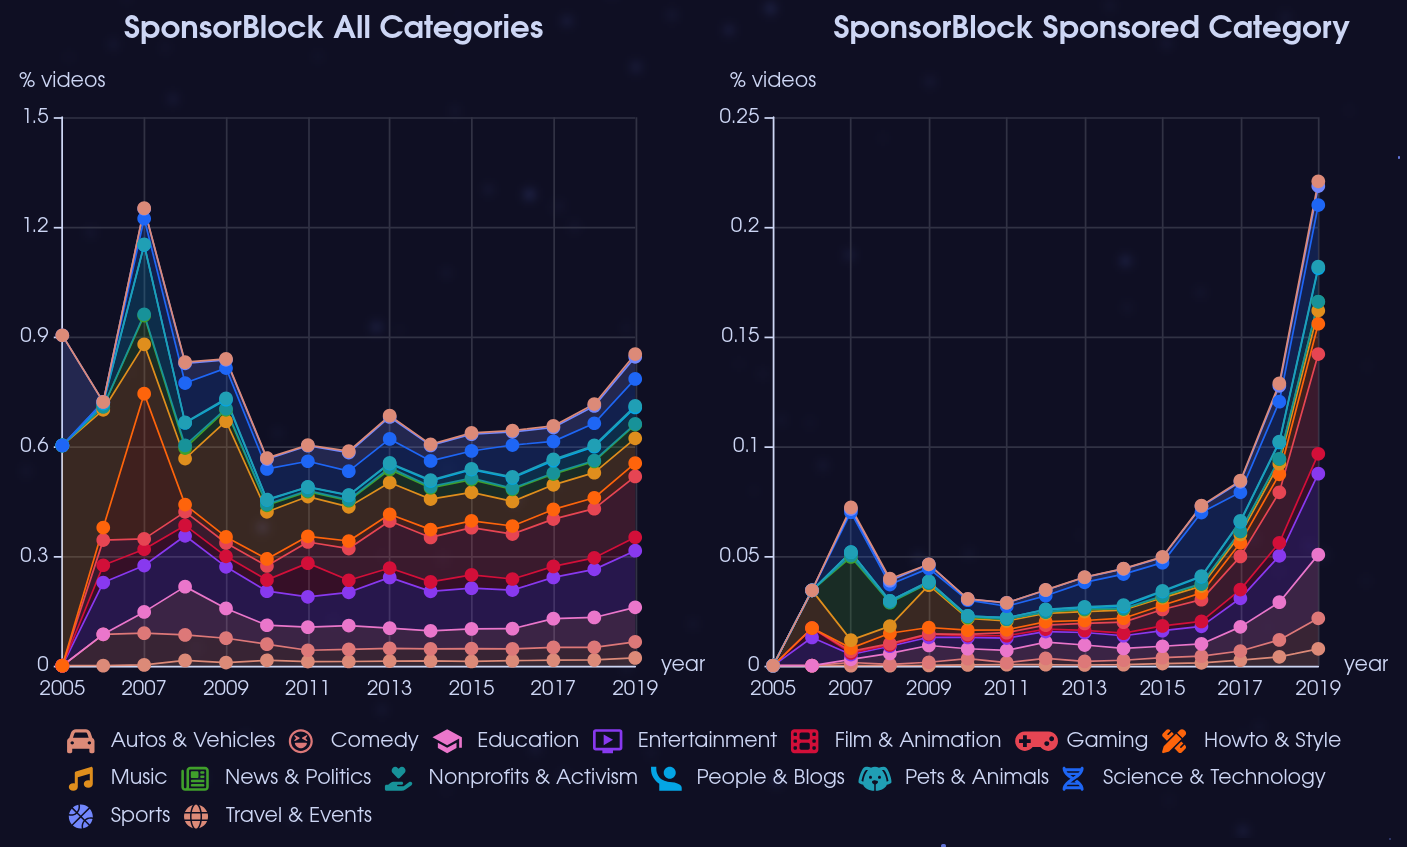


### 2. How long before I get sponsored? ([channelsponsortimeline](analysis/channelsponsortimeline/src/main.rs))

To generate the plot below, we needed to find the first sponsored video a
channel produced. We could then compare the upload date to that of the first
ever video by that channel to obtain the time delta, and count how many videos
the channel published between its first video and its first sponsored video to
obtain the video delta:

```rust
let (diffs, nbef): (Vec<N64>, Vec<N64>) = sponvids
    .values()
    .filter_map(|videos| {
        let [ref first_nspon, ..] = videos.not_sponsored[..] else {
            return None;
        };
        let [ref first_spon, ..] = videos.sponsored[..] else {
            return None;
        };
        if first_spon.upload_date > first_nspon.upload_date {
            Some((
                first_spon.upload_date - first_nspon.upload_date,
                videos
                    .not_sponsored
                    .iter()
                    .filter(|e| e.upload_date < first_spon.upload_date)
                    .count(),
            ))
        } else {
            None
        }
    })
    .map(|(d, n)| (n64(d.num_days() as f64), n64(n as f64)))
    .collect();
```

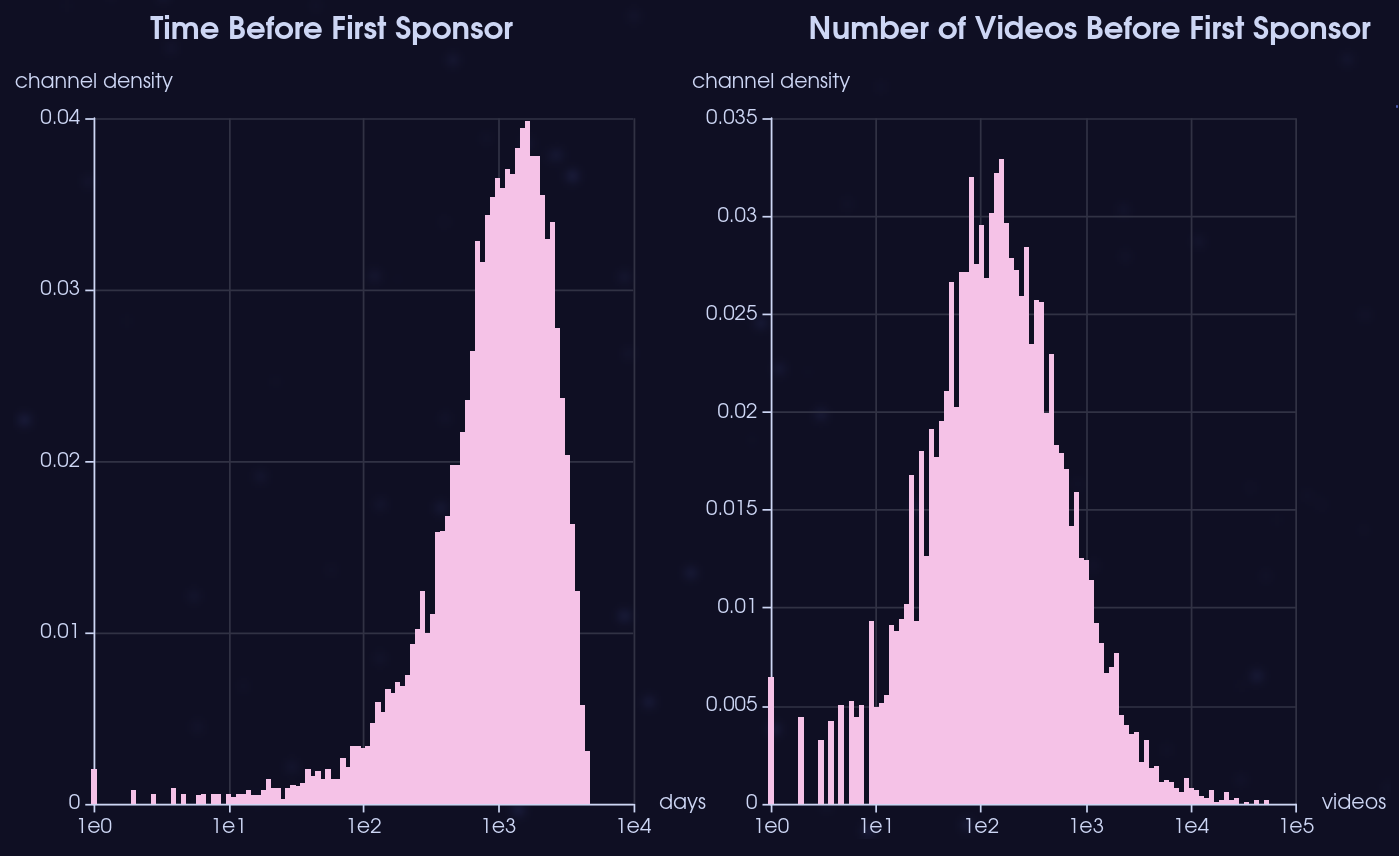

### 3. What stats do channels have when they get sponsored? ([channelsponsorsubs](analysis/channelsponsorsubs/src/main.rs))

For this plot, various channel statistics (views, subs, videos, and activity)
had to be looked up at the time of a channel's first sponsor. Thus, these
metrics had to be extracted from `df_timeseries_en.tsv.gz`:

```rust
reader.lines().enumerate().for_each(|(i, read_line)| {
    // ...
    let cat_str = splits.next().unwrap();
    let category = match CATEGORIES.iter().position(|&e| e == cat_str) {
        Some(e) => e,
        None => {
            // ...
        }
    };

    let date_str = splits.next().unwrap();
    let parsed =
        NaiveDateTime::parse_from_str(&date_str, "%Y-%m-%d %H:%M:%S")
            .unwrap();
    let timepoint = DateTime::<Utc>::from_naive_utc_and_offset(parsed, Utc);

    let views: f64 = splits.next().unwrap().parse().unwrap();
    let subs: f64 = splits.nth(1).unwrap().parse().unwrap();
    let videos: f64 = splits.nth(1).unwrap().parse().unwrap();
    let activity: f64 = splits.nth(1).unwrap().parse().unwrap();

    assert!(splits.count() == 0);

    let entry = timeseries.entry(channel_id.to_owned()).or_insert(vec![]);
    entry.push(ChannelTimePoint {
        timepoint,
        views,
        subs,
        videos,
        activity,
        category,
    });
});
```

These metrics were then aggregated in a category-specific manner. We look up the
channel time point closest to the first sponsored upload:

```rust
let (view_thresh, sub_thresh, vid_thresh, act_thresh, cats): (
    Vec<N64>,
    Vec<N64>,
    Vec<N64>,
    Vec<N64>,
    Vec<usize>,
) = sponvids
    .iter()
    .filter_map(|(channel_id, videos)| {
        let vid = videos.sponsored.first().unwrap();
        let Some(points) = timeseries.get(channel_id) else {
            return None;
        };

        let ChannelTimePoint {
            views,
            subs,
            videos,
            activity,
            category,
            ..
        } = points
            .iter()
            .min_by(|a, b| {
                let delta_a = (a.timepoint - vid.upload_date).abs();
                let delta_b = (b.timepoint - vid.upload_date).abs();
                delta_a.cmp(&delta_b)
            })
            .unwrap();
        Some((
            n64(*views),
            n64(*subs),
            n64(*videos),
            n64(*activity),
            category,
        ))
    })
    .collect();
```

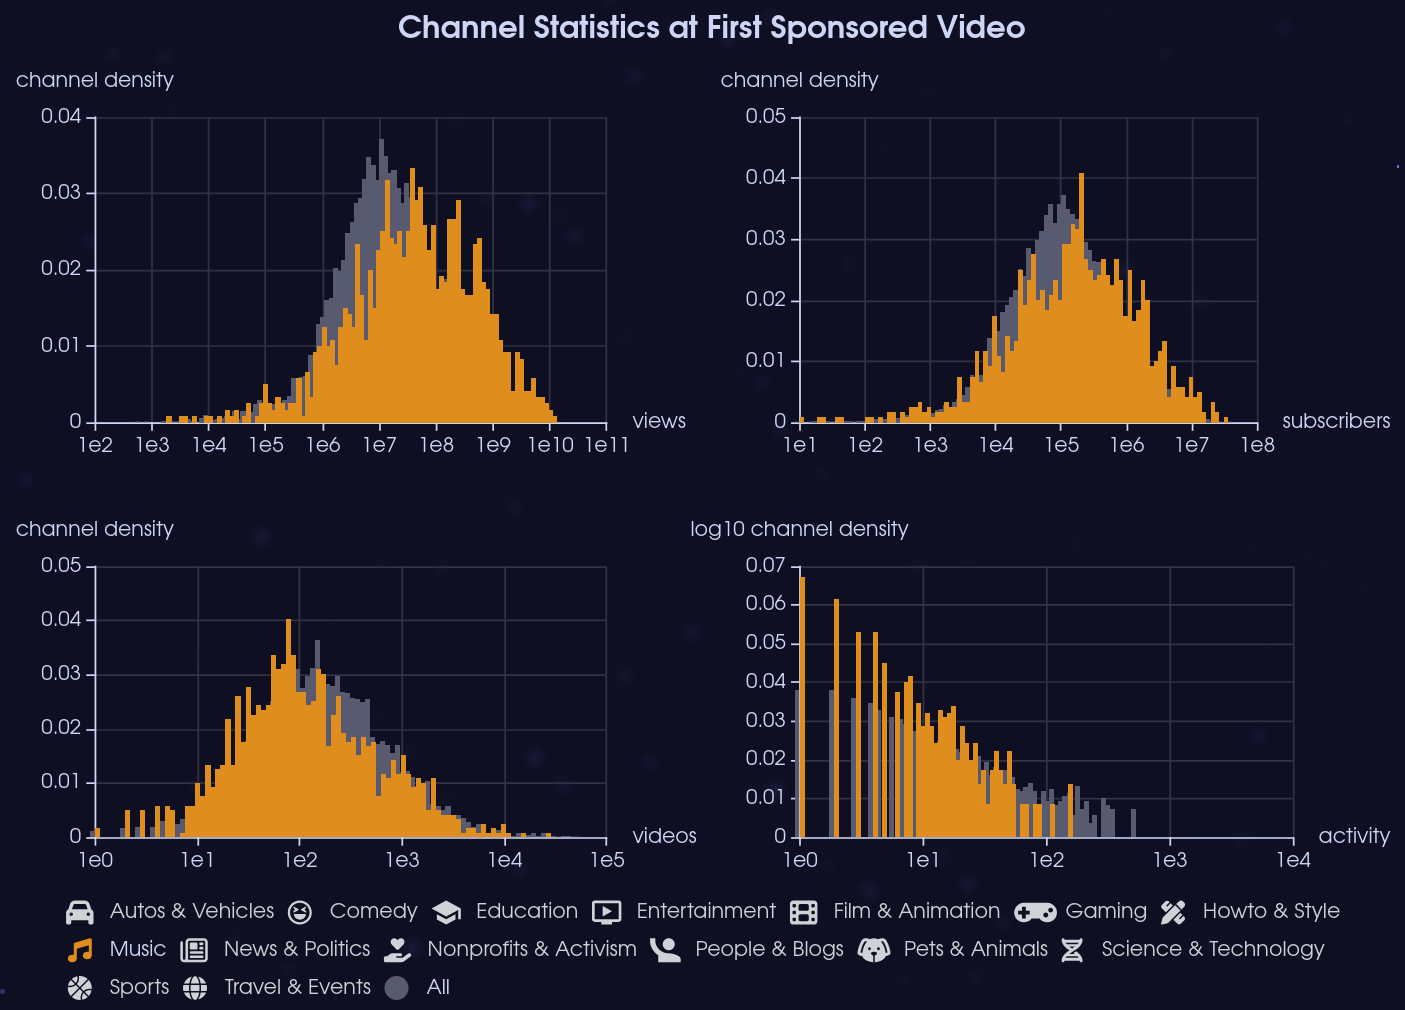

### 4. Do people switch categories when they get sponsored? ([catswitch](analysis/catswitch/src/main.rs))

To generate this graph, we needed to select the six months before and after the
first sponsored upload (the `filter_map` below). We then needed to look up the
categories of each video in each time frame and compute the most common before
and after (the `map` below). Finally, we counted the number of each category
transition (the `fold` below).

```rust
let window = Duration::days(6 * 30);
let transitions: HashMap<(usize, usize), u32> = sponvids
    .into_values()
    .filter_map(|videos| {
        let [ref first_spon, ..] = videos.sponsored[..] else {
            return None;
        };
        let spon_date = first_spon.upload_date;

        let before: Vec<usize> = videos
            .not_sponsored
            .iter()
            .filter(|e| {
                (spon_date > e.upload_date)
                    && (spon_date - e.upload_date <= window)
            })
            .filter_map(|e| catmap.get(&e.display_id))
            .cloned()
            .collect();

        if before.is_empty() {
            return None;
        }

        let after: Vec<usize> = videos
            .sponsored
            .into_iter()
            .chain(videos.not_sponsored)
            .filter(|e| {
                (spon_date <= e.upload_date)
                    && (e.upload_date - spon_date <= window)
            })
            .filter_map(|e| catmap.get(&e.display_id))
            .cloned()
            .collect();

        Some((before, after))
    })
    .map(|(b, a)| {
        let mut b_map = HashMap::<usize, u32>::new();
        b.into_iter().for_each(|e| {
            let entry = b_map.entry(e).or_insert(0);
            *entry += 1;
        });
        let (b_max, _) = b_map.drain().max_by_key(|(_, e)| *e).unwrap();

        let mut a_map = HashMap::<usize, u32>::new();
        a.into_iter().for_each(|e| {
            let entry = a_map.entry(e).or_insert(0);
            *entry += 1;
        });
        let (a_max, _) = a_map.drain().max_by_key(|(_, e)| *e).unwrap();

        (b_max, a_max)
    })
    .fold(HashMap::new(), |mut acc, e| {
        *acc.entry(e).or_insert(0) += 1;
        acc
    });
```

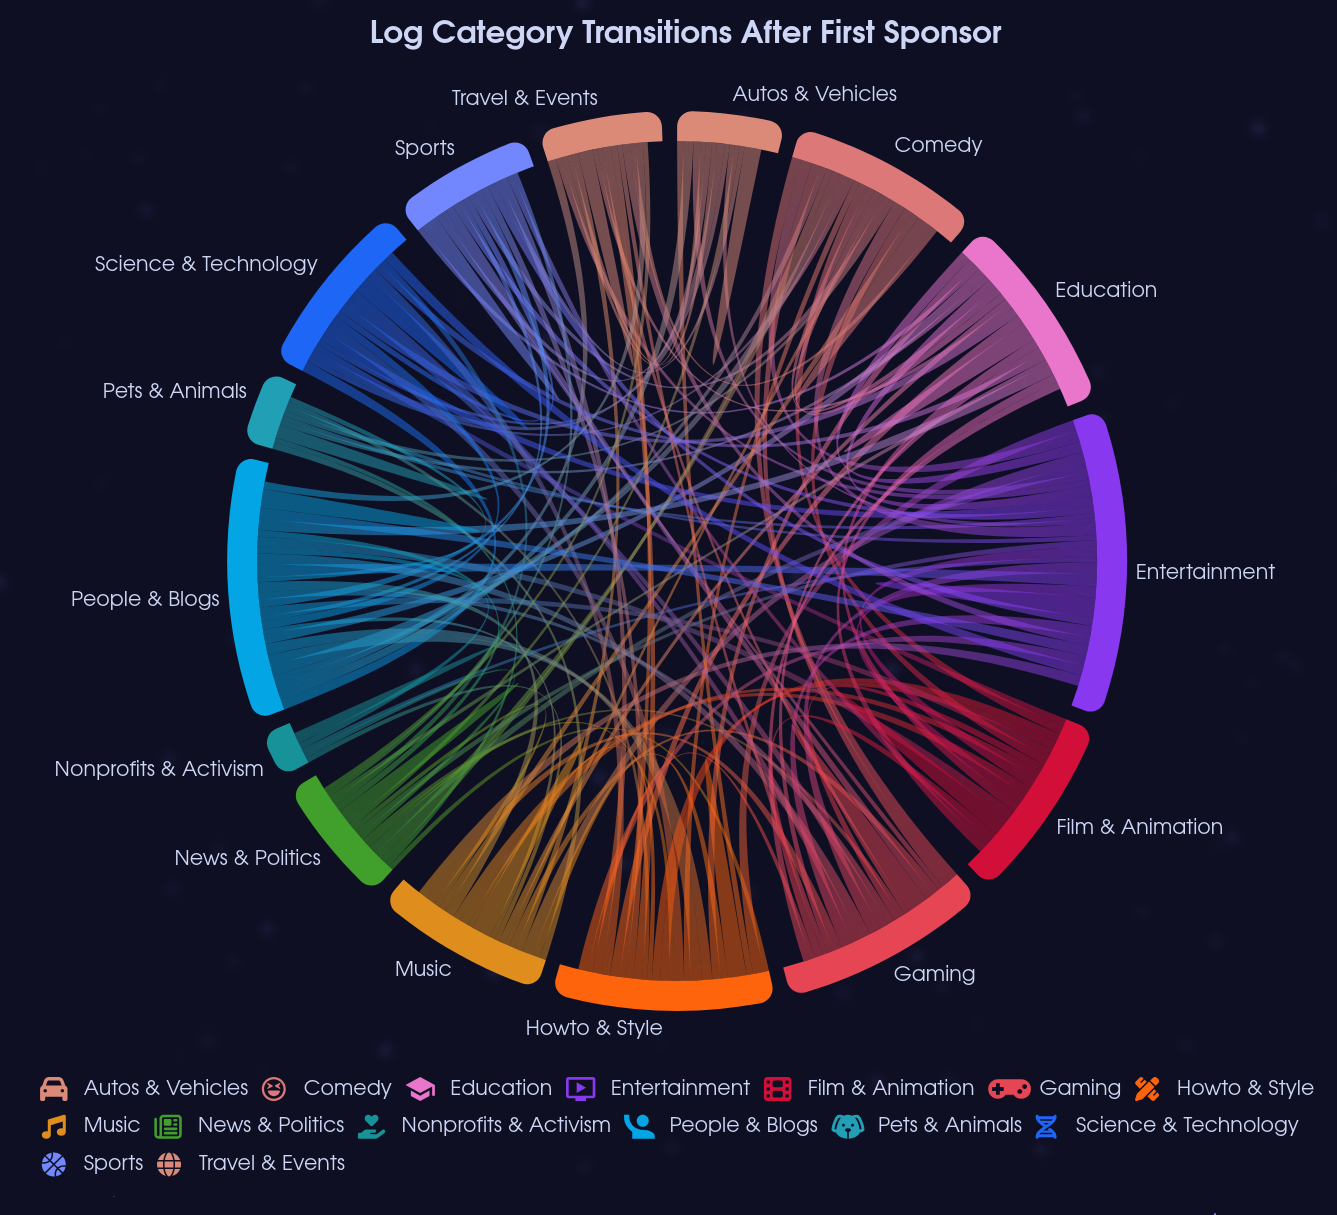

### 5. Are sponsored channels more active long-term? ([channelsponsoractive](analysis/channelsponsoractive/src/main.rs))

Here, we needed to compute the proportions of active/inactive channels in 2025
for sponsored and unsponsored channels per category. This was done for all four
combinations and for sponsored and unsponsored separately. This allows the
visualisation to show the global normalised proportions or the
sponsored/unsponsored proportions.

```rust
let mut counts = [[0u64; 4]; CATEGORIES.len()];
reader
    .lines()
    .skip(1)
    .enumerate()
    .for_each(|(i, read_line)| {
        // ...
        if active {
            if sponsored.contains(channel_id) {
                counts[cat_ind][0] += 1;
            } else {
                counts[cat_ind][1] += 1;
            }
        } else {
            if sponsored.contains(channel_id) {
                counts[cat_ind][2] += 1;
            } else {
                counts[cat_ind][3] += 1;
            }
        }
    });
```

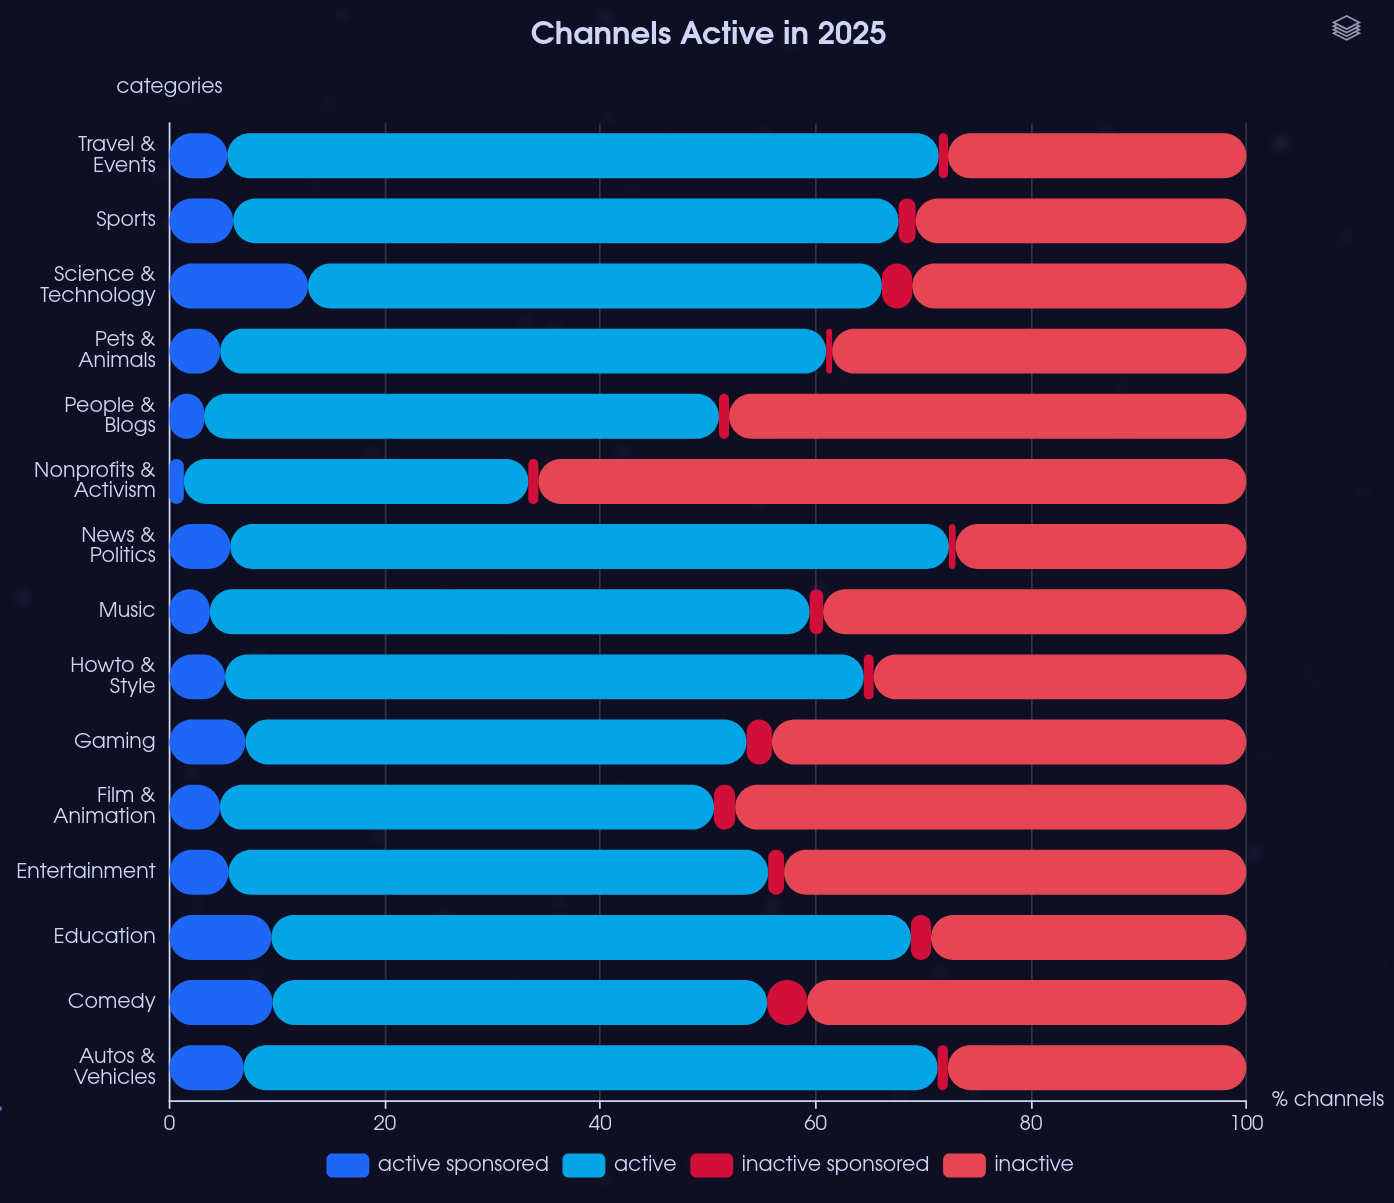
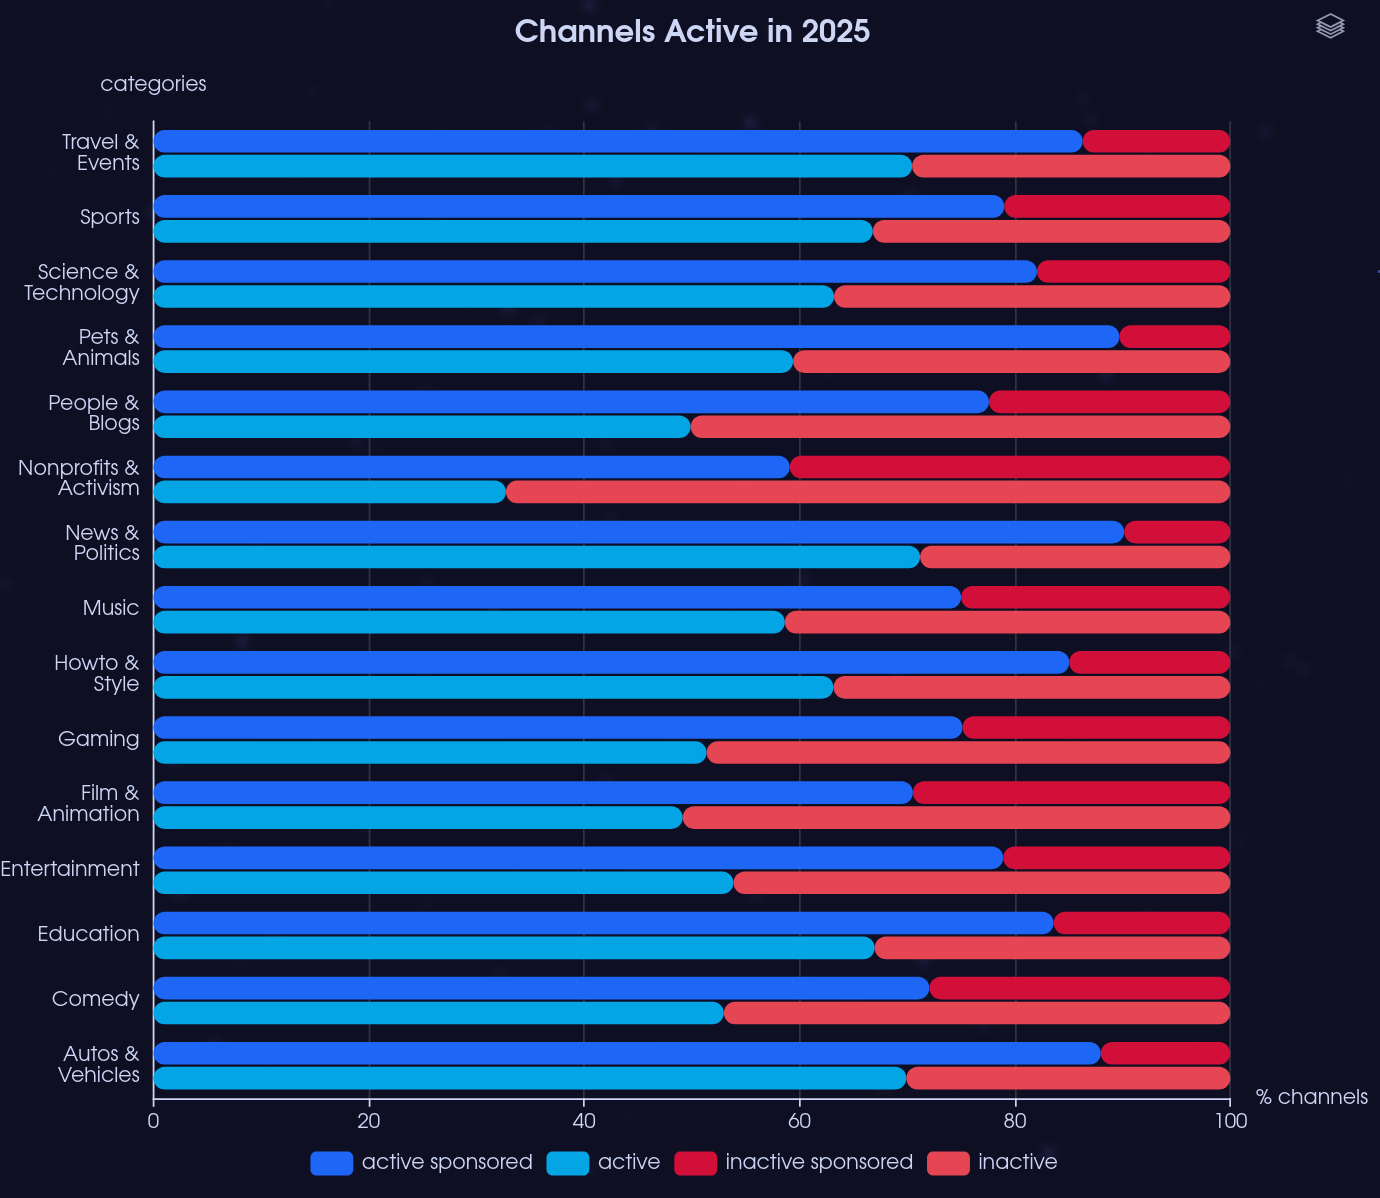

### 6. Making a large dynamic graph run on the web ([graphsite](graphsite/src/app/mod.rs))

Due to the large size and high connectivity of the graph we wanted to visualise,
loading and rendering it on a website was particularly challenging. Without
going into the details too much, a custom graph was implemented using the Rust
library [egui_graphs](https://github.com/blitzarx1/egui_graphs) and compiled
into a [WebAssembly](https://webassembly.org/) binary to be served on the site.

The graph definition files were bundled directly into the binary as
zstd-compressed objects:

```rust
let gzipped = include_bytes!("../../changraph.json.gz");
let mut deco = GzDecoder::new(Vec::new());
deco.write_all(gzipped).unwrap();
let base_graph: StableUnGraph<(String, String), usize> =
    serde_json::from_slice(&deco.finish().unwrap()).unwrap();

let gzipped = include_bytes!("../../changraphprops.json.gz");
let mut deco = GzDecoder::new(Vec::new());
deco.write_all(gzipped).unwrap();
let graph_props: Vec<SerProps> =
    serde_json::from_slice(&deco.finish().unwrap()).unwrap();
```

The ui was implemented using [egui](https://github.com/emilk/egui). The largest
performance improvement apart from using WASM was to only render the edges
of selected nodes, even if all edges are still used for the force-directed
layout computation:

```rust
if start.selected()
    || start.dragged()
    || start.hovered()
    || end.selected()
    || end.dragged()
    || end.hovered()
{
    self.default_impl.shapes(start, end, ctx)
} else {
    vec![]
}
```

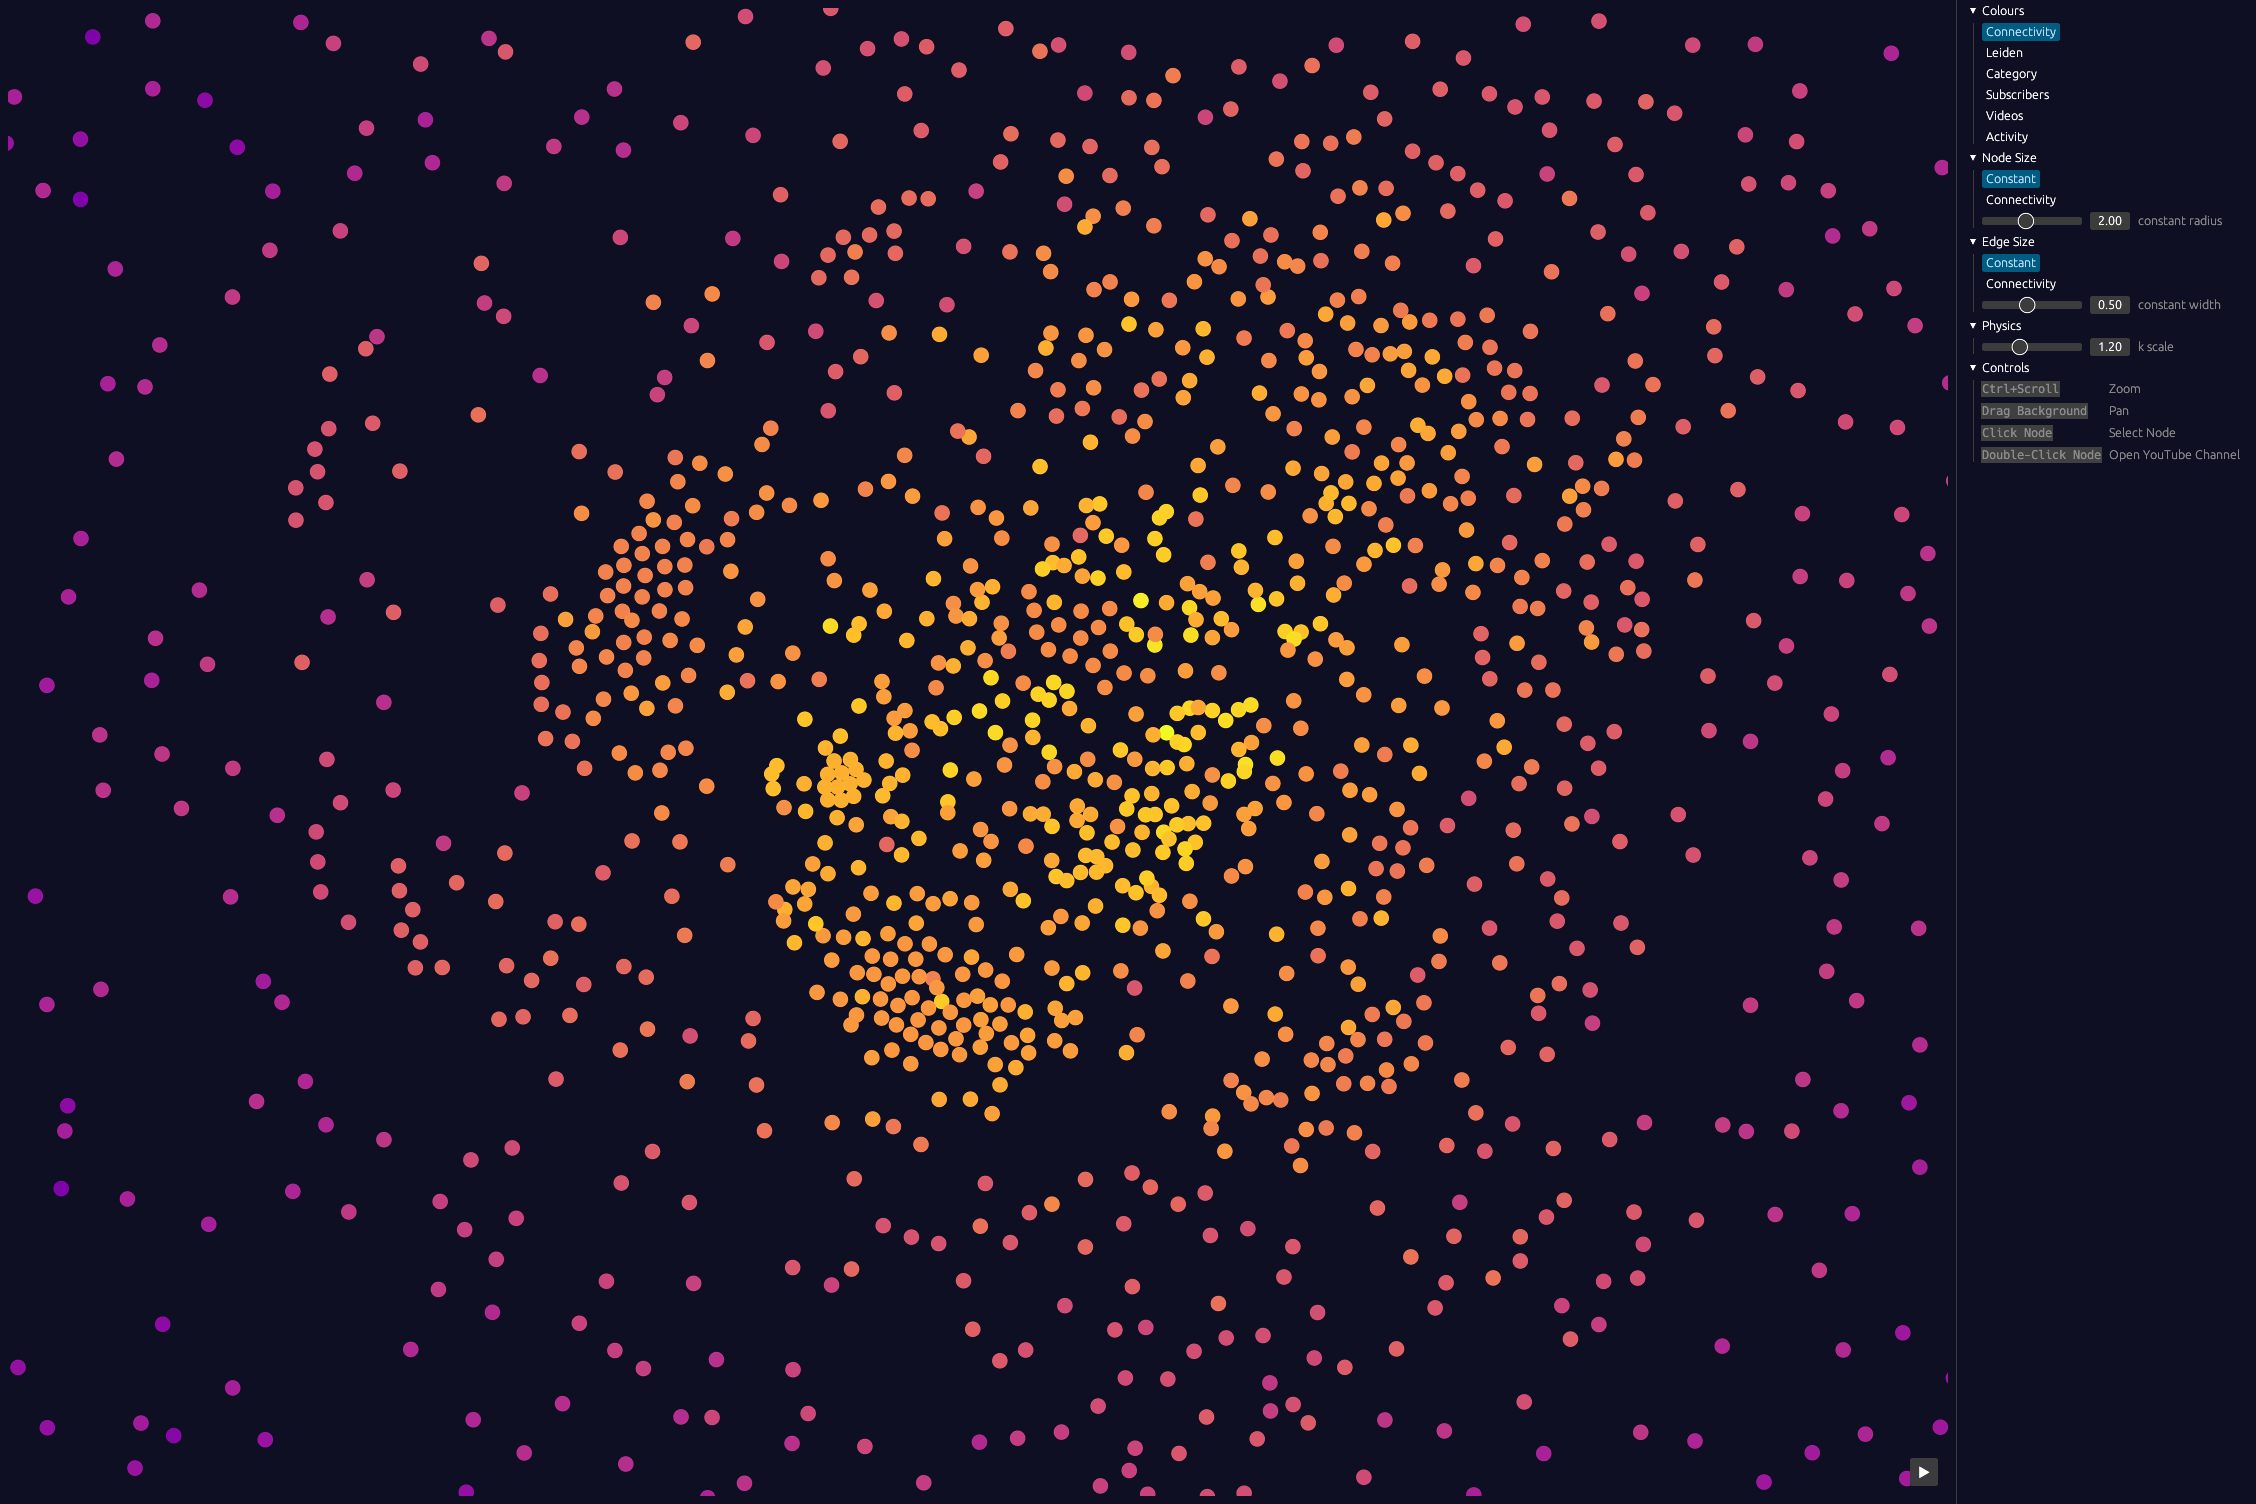

## How does a focus on professionalism affect engagement?

### 1. Dumbbell plot comparing sponsored vs nonsponsored videos

The plot in this part is a dumbbell plot comparing metrics for sponsored vs nonsponsored videos within sponsored channels. The first step is to gather data from different files in order to make the plot, and the code used to do this is found in [./process/rq3_processing/rq3_build_data_dumbbell.py](./process/rq3_processing/rq3_build_data_dumbbell.py), with the main steps described below.

The aim here is to get information about every video within channels that are at least registered five times in SponsorBlock for having in-video sponsor segment. This will be used to create a plot comparing sponsored vs nonsponsored video metrics (like/dislike ratio, duration and number of views).

First, only channels with at least five videos in SponsorBlock are kept:
```python
    df_gt5 = df_sc[df_sc["video_ids"].apply(len) >= 5]
```

Then, to collect the metadata of the videos of interest, the metadata file is read in chunks due to its large size, and only a subset of the metrics are gathered for the plot:
```python
    meta_chunks = pd.read_json(
            METADATA_FILE,
            lines=True,
            chunksize=1_000_000,
            compression="gzip"
        )

    # ...

    subset = chunk.loc[mask, ["categories",
                              "channel_id",
                              "display_id",
                              "dislike_count",
                              "duration",
                              "like_count",
                              "view_count"
                              ]
                        ]
```

Finally, the like/dislike ratio, defined as $\frac{\text{likes}}{\text{likes+dislikes}} \cdot 100$, is computed. In addition, the videos are specified as "sponsored" or not:

```python
    dislikes = df_step1["dislike_count"]
    likes = df_step1["like_count"]
        
    df_step1["like_dislike_ratio"] = (likes/(likes+dislikes))*100
        
    df_step1["sponsored"] = df_step1["display_id"].isin(sponsored_videos_ids)
```


Then, the aim is to get a json file with all the values used for plotting (the code to do that is located in [./analysis/rq3_analysis/rq3_dumbbell_data.py](./analysis/rq3_analysis/rq3_dumbbell_data.py)). 

Using aggregation, the median of the metrics are computed per channel in each category and then the median of these previously computed medians are calculated (the procedure is more detailed on the website):
```python
    per_channel = (
        df.groupby(["categories", "channel_id"])[metric_col]
        .median()
        .reset_index()
    )

    agg = (
        per_channel.groupby("categories")[metric_col]
        .median()
        .sort_values(ascending=False)
    )
```

Also, the sponsored and nonsponsored videos are separated,

```python
df_non = df[~df["sponsored"]].copy()  
df_spon = df[df["sponsored"]].copy() 
```
and are used to obtain `ratio_non`, `ratio_spon`, `duration_non`, `duration_spon`, `views_non` and `views_spon`. For instance, `duration_spon` corresponds to the computed duration medians in sponsored videos for each categories.

At the end, the values used for the plot are saved in the following dictionary:
```python
    second_plot_data = {
        "categories": cat_order,
        "metrics": {
            "ratio": {
                "non_sponsored": ratio_non,
                "sponsored": ratio_spon,
            },
            "duration": {
                "non_sponsored": duration_non,
                "sponsored": duration_spon,
            },
            "views": {
                "non_sponsored": views_non,
                "sponsored": views_spon,
            },
        },
    }
```
These saved values can be found in [./analysis/rq3_analysis/rq3_dumbbell_data.json](./analysis/rq3_analysis/rq3_dumbbell_data.json) and are directly used to produce the dumbell plot in [./analysis/rq3_analysis/rq3_dumbbell.py](./analysis/rq3_analysis/rq3_dumbbell.py).

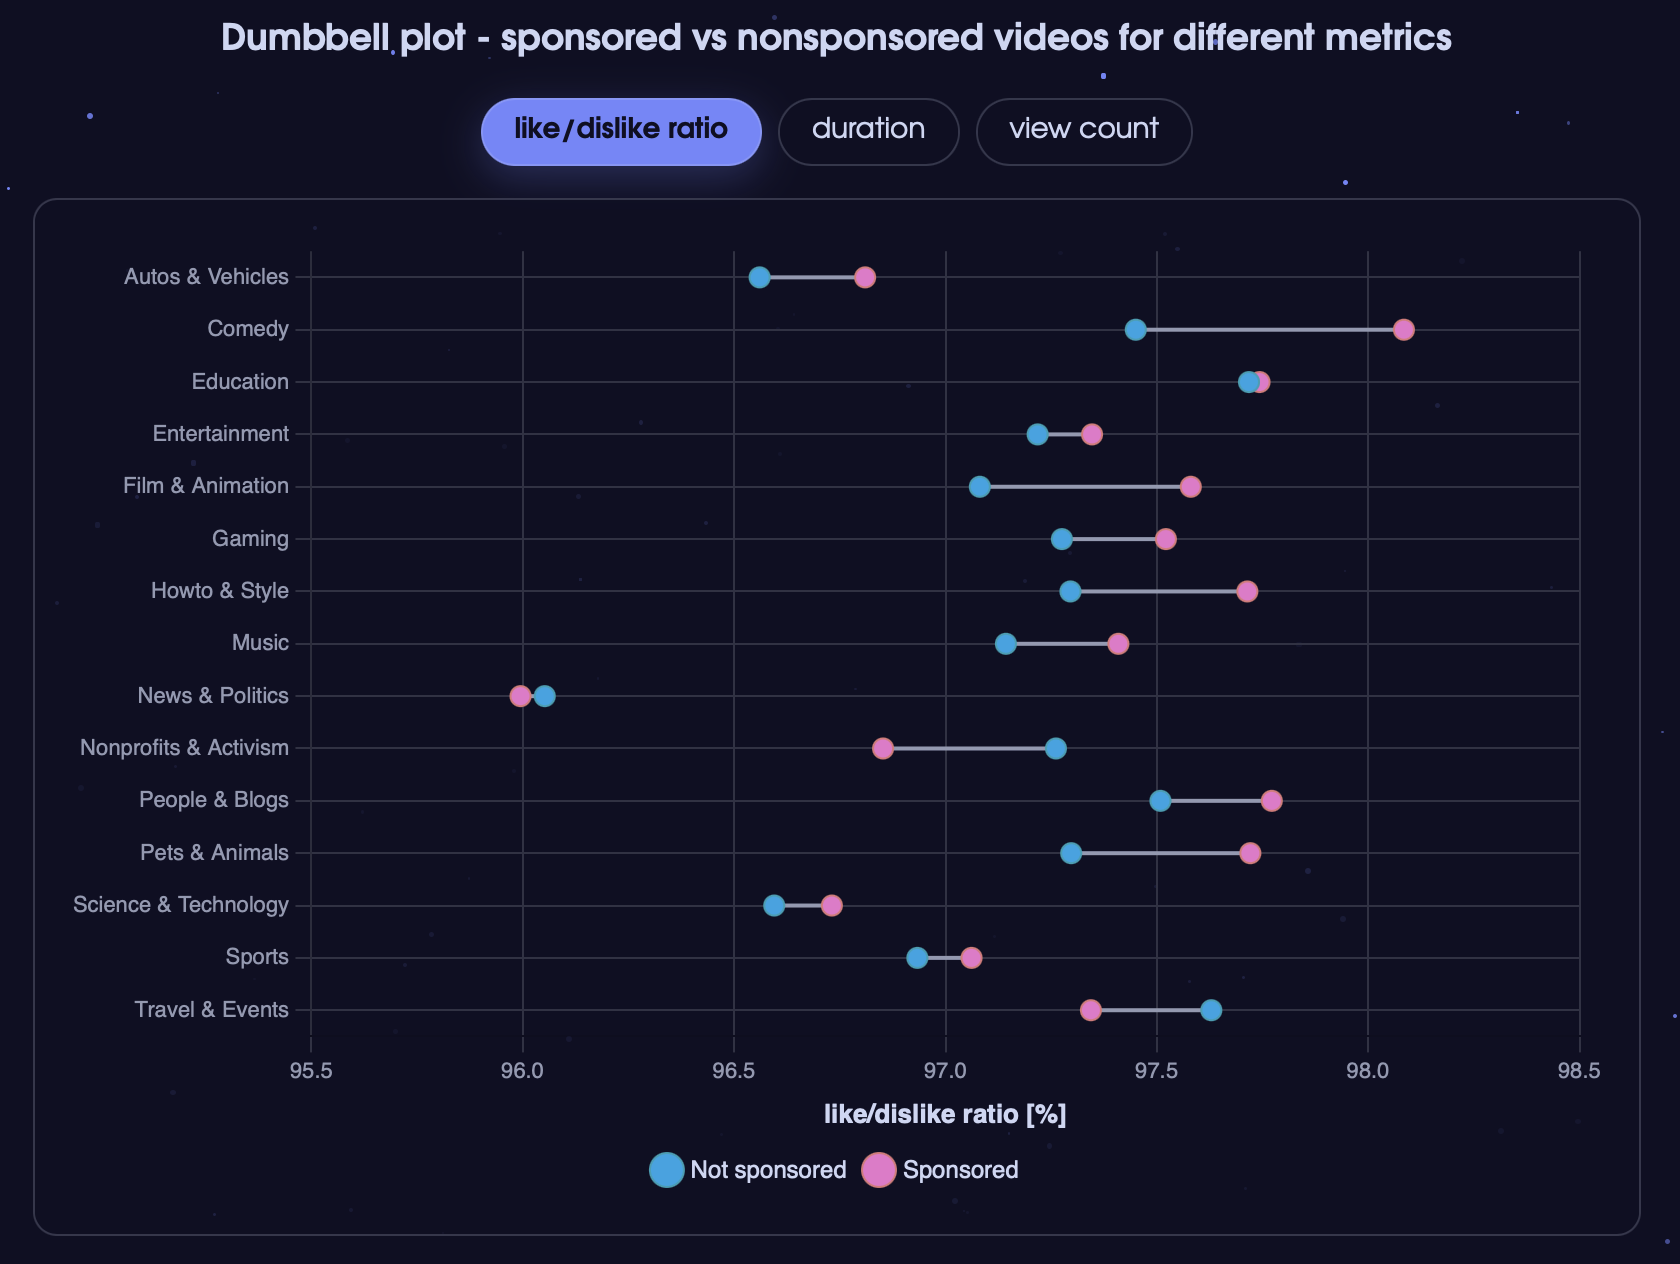


## 2. Plot showing what happens to delta_views and delta_subs around the first sponsor appearance

This plot also requires gathering data from multiple files. In [./process/rq3_processing/rq3_build_data_delta_views_subs.py](./process/rq3_processing/rq3_build_data_delta_views_subs.py), the preprocessing steps are done, with the most important milestones described here.

The aim is to get time-series information about channels that are at least registered once in SponsorBlock for having in-video sponsor segment. This will be used to create a plot showing the changes happening to the channels stats (weekly change in views and subscribers) around the first-ever sponsor appearance.

First of all, as with the first plot, the metadata file used to get information about the videos is read in chunks, but this time, only `channel_id`, `display_id` and `upload_date` metadata is kept for the videos of interest:
```python
    subset = chunk.loc[mask, ["channel_id", "display_id", "upload_date"]]
```

The upload date is converted to a pandas datetime object (for further computation):
```python
    df_meta_sponsor["upload_date"] = pd.to_datetime(df_meta_sponsor["upload_date"])
```

Then, the time-series data is collected for the channels of interest and the same convertion to datetime object is applied to `datetime`, which corresponds to every week data is gathered for a channel in the time-series:
```python
    df_ts = pd.read_csv(
        TIMESERIES_FILE, 
        sep="\t", 
        compression="gzip",
        usecols=["channel", "datetime", "views", "delta_views", "subs", "delta_subs"]
        )

    df_ts["datetime"] = pd.to_datetime(df_ts["datetime"])
```

Finally, the cornerstone of this plot is getting the weeks before and after the first sponsor appearance. To do that, the first step is to find the date of the earliest sponsored video within each channel in a new column `sponsor_start`. Then, this value is substracted from each `datetime` in the time-series. This difference is then converted to days and eventually the floor division with 7 is taken to compute the relative weeks from the first sponsor. For example, in that case week 0 is defined as the time window from 0 to 6 days after the first sponsor appearance (inclusive).
```python
    min_per_channel = (
        df_step2[["channel_id", "upload_date"]]
        .groupby("channel_id")["upload_date"]
        .min()                      
    )    

    df_step3["sponsor_start"] = df_step3["channel_id"].map(min_per_channel)

    df_step3["delta_weeks"] = (
    (df_step3["datetime"] - df_step3["sponsor_start"]).dt.days // 7
    )
```


The code for plotting is located in [./analysis/rq3_analysis/rq3_delta_views_subs.py](./analysis/rq3_analysis/rq3_delta_views_subs.py), and below is the presentation of the main steps.

Only the 26 weeks before and after the first sponsor are kept to cover a full year:
```python
    df_keep = df[df["delta_weeks"].between(-26, 26, inclusive="both")].copy()
```

Then, the logarithm of the metric (either `delta_views` or `delta_subs`) is taken. More specifically, numpy's `log1p` (computing log(1 + x)) is used, making sure any possible undefined logarithm computations are avoided. This step is followed by the aggregation across channels considering the relative weeks to the first sponsor (`delta_weeks`), where new columns are created to get the mean, standard deviation and count for every relative week.
```python
    log_col = f"log_{metric_col}"
    df_temp[log_col] = np.log1p(df_temp[metric_col].clip(lower=0))

    df_plot = (
        df_temp.groupby("delta_weeks", as_index=False)
        .agg(
            mean_log_val=(log_col, "mean"),
            std_log_val=(log_col, "std"),
            n=(log_col, "size")
        )
        .sort_values("delta_weeks")
    )
```

To quantify uncertainty around the calculated means, 95% confidence intervals are computed using the following formula: 
$$
CIs = \bar{x} \pm 1.96 \cdot SE,
$$
where $\bar{x} = \frac{1}{n} \sum x_i$ is the sample mean and $SE = \frac{\text{sample standard deviation}}{\sqrt{\text{number of elements}}} = \frac{s}{\sqrt n}$ is the standard error.
```python
    df_plot["se"] = df_plot["std_log_val"] / np.sqrt(df_plot["n"])
    df_plot["ci_lower"] = df_plot["mean_log_val"] - (1.96 * df_plot["se"])
    df_plot["ci_upper"] = df_plot["mean_log_val"] + (1.96 * df_plot["se"])
```

Finally, all the values used in the plot are saved in the following dictionary:
```python
    {
        "delta_weeks": df_plot["delta_weeks"].tolist(),
        "mean_log_val": df_plot["mean_log_val"].tolist(),
        "ci_lower": df_plot["ci_lower"].tolist(),
        "ci_upper": df_plot["ci_upper"].tolist(),
    }
```

and these are directly used for plotting within the same file.

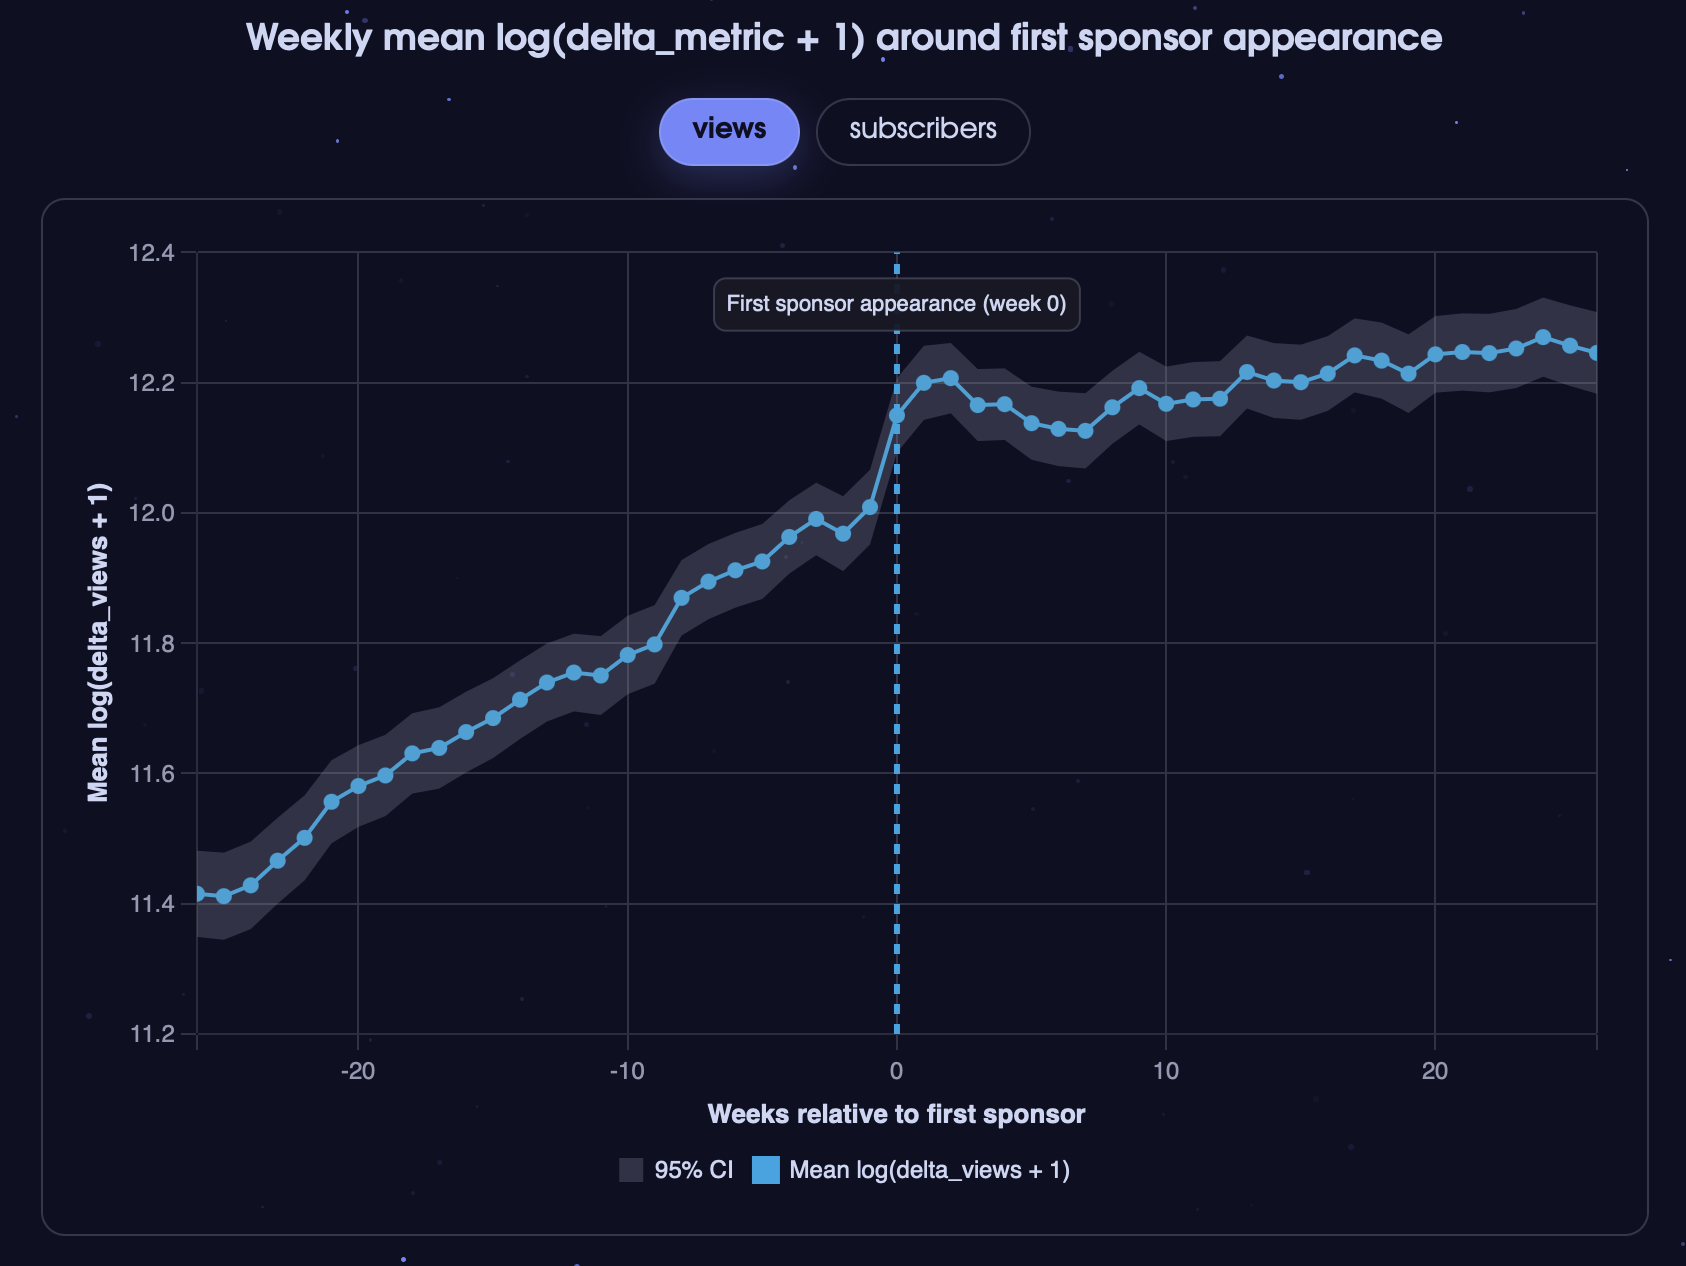

# 1-Measuring the Evolution of External Linking on YouTube
In this section, we build a small pipeline to turn raw URLs into interpretable link categories and measure how different types of links are adopted over time on YouTube.


We compute per-year link adoption for each YouTube category. We query the JSONL
files (`yt_metadata_en.jsonl.gz`, `urls.jsonl.gz`) using DuckDB. We join URLs to
videos, detect whether each video contains links of a given type, and aggregate
everything by year.

The result is a table showing how different link types evolve over time within a
single YouTube category.

Then, compute yearly link adoption stats. Each link group is a reusable SQL
filter, we can plug them straight into a DuckDB query.

1. we read the metadata and urls JSONL files directly in DuckDB.
1. we left-join urls onto videos using `display_id`, so videos without urls are
   still counted.
1. we use the group conditions to create boolean flags like `has_monetization`,
   `has_social`, etc.
1. we aggregate these flags by year to get a compact table of link adoption over
   time for a given YouTube category.

```python
def category_stats_multi(
    meta_path: str,
    urls_path: str,
    yt_category: str,
    domains_df: pd.DataFrame,
    group_to_merged: Mapping[str, List[str]] = GROUP_TO_MERGED,
    show_progress: bool = True,
) -> pd.DataFrame:
    if show_progress:
        duckdb.query("PRAGMA enable_progress_bar;")

    group_conditions = build_group_conditions_merged(domains_df, group_to_merged)

    cond_monet = group_conditions.get("monetization", "FALSE")
    cond_cont  = group_conditions.get("content", "FALSE")
    cond_soc   = group_conditions.get("social", "FALSE")

    cat = yt_category.replace("'", "''")

    base_cte = f"""
    WITH base AS (
        SELECT
            CAST(strftime(CAST(m.upload_date AS TIMESTAMP), '%Y') AS INTEGER) AS year,
            m.display_id,
            (u.urls IS NOT NULL) AS has_urls,

            (u.urls IS NOT NULL AND ({cond_monet})) AS has_monetization,
            (u.urls IS NOT NULL AND ({cond_cont}))  AS has_content,
            (u.urls IS NOT NULL AND ({cond_soc}))   AS has_social

        FROM read_json_auto('{meta_path}', format='newline_delimited') AS m
        LEFT JOIN read_json_auto('{urls_path}', format='newline_delimited') AS u
            USING (display_id)
        WHERE m.categories = '{cat}'
    )
    """

    query = base_cte + """
    SELECT
        year,
        COUNT(*) AS videos_total,
        SUM(CASE WHEN has_urls THEN 1 ELSE 0 END) AS videos_with_urls,
        SUM(CASE WHEN has_monetization THEN 1 ELSE 0 END) AS videos_with_monetization,
        SUM(CASE WHEN has_content THEN 1 ELSE 0 END) AS videos_with_content,
        SUM(CASE WHEN has_social THEN 1 ELSE 0 END) AS videos_with_social
    FROM base
    GROUP BY year
    ORDER BY year;
    """

    return duckdb.query(query).df()
```


After applying this for every YouTube category, we end up with one row per
`(year × category)` that summarizes how often different types of links appear.

Here are a few sample rows from the final output, focusing on the main link
groups used in the analysis:

| year | yt_category            | videos_total | videos_with_urls | videos_with_monetization | videos_with_content | videos_with_social |
|-----:|------------------------|-------------:|-----------------:|--------------------------:|--------------------:|-------------------:|
| 2007 | Autos & Vehicles       | 7,366        | 3,227            | 111                       | 426                 | 967                |
| 2008 | Science & Technology   | 17,317       | 8,952            | 774                       | 1,453               | 1,330              |
| 2009 | News & Politics        | 67,463       | 17,526           | 711                       | 1,473               | 3,466              |
| 2011 | People & Blogs         | 97,349       | 48,277           | 6,101                     | 16,902              | 21,301             |
| 2011 | Howto & Style          | 108,199      | 73,403           | 11,831                    | 26,330              | 33,005             |
| 2019 | Comedy                 | 151,984      | 105,061          | 31,602                    | 60,463              | 69,343             |


- `videos_total` shows overall production volume for each category and year  
- `videos_with_urls` indicates how common external linking is  
- The remaining columns highlight how often creators link to monetization, content, and social destinations

This simplified view makes cross-category comparisons easier and keeps the focus
on the most informative link types. For this part, we intentionally leave out
some links such as news links, since their presence is tightly tied to specific
categories. The goal here is to highlight the broader evolution of linking
behavior from early indie style content toward more structured industry like
practices.

Note: This section relies on helper functions defined in `link_channels_helper`.

## 1.2 Resulting plots with obtained data

Using the yearly link adoption table produced by `category_stats_multi(...)`, we
now visualize how YouTube content and linking behavior evolve over time across
categories.

Each plot aggregates results at the category-year level and is designed to
highlight long-term structural trends, rather than short-term fluctuations. The
focus here is on how YouTube shifts from an early, indie-driven ecosystem toward
a more mature, industry-like platform.

### From Indie to Industry: Growth of YouTube Uploads (2008–2018)
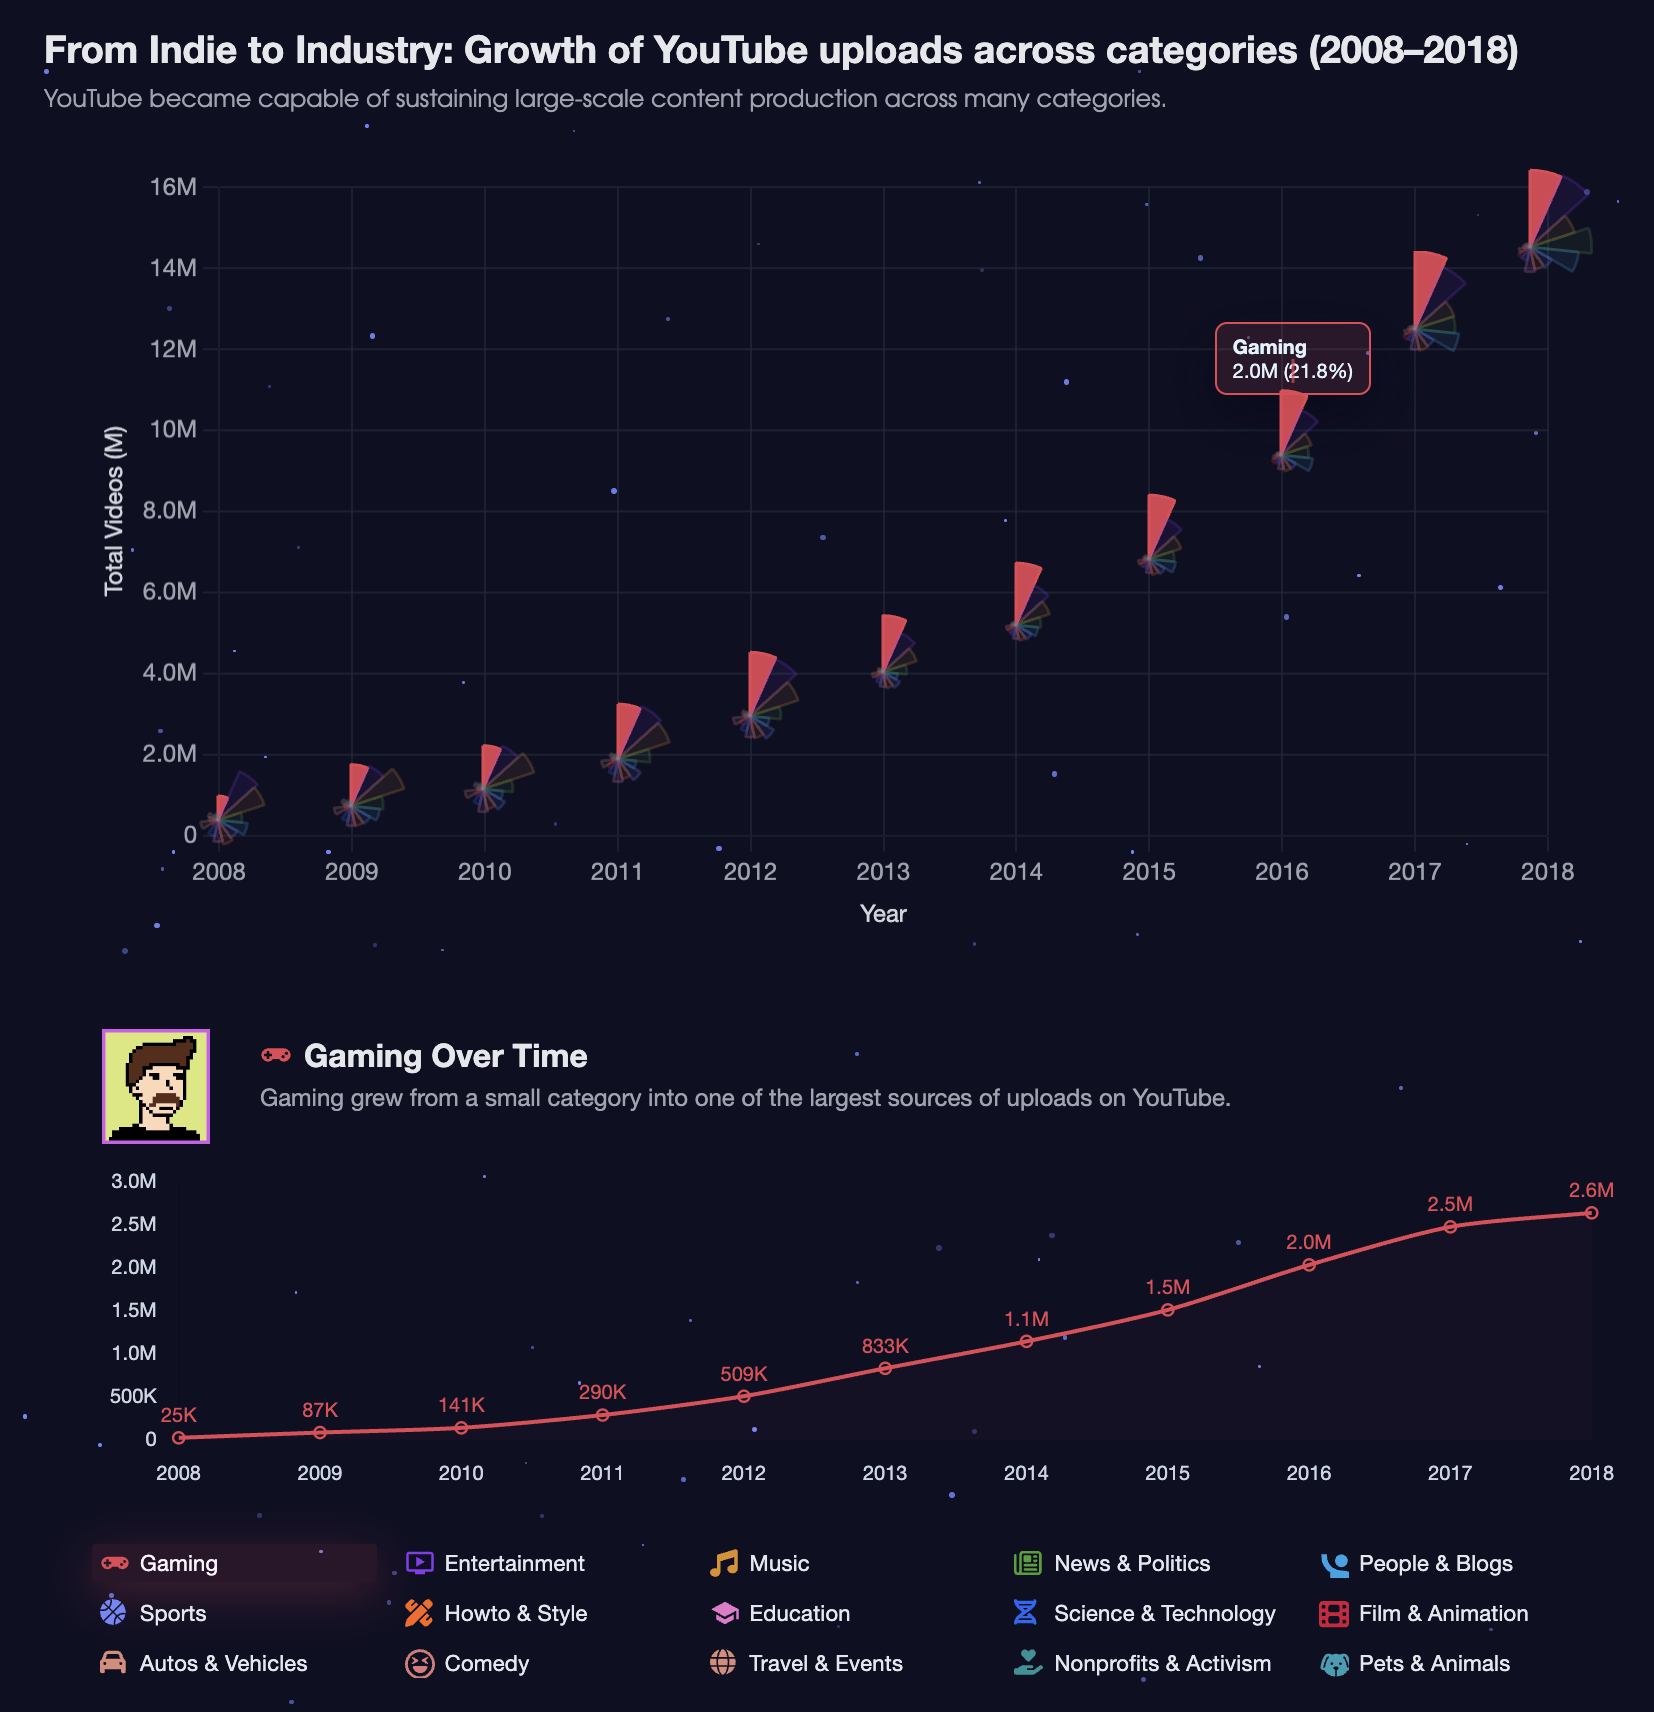

**Figure 1.** Growth in the number of YouTube uploads across categories between 2008 and 2018.

### How Creators Learned to Use Links on YouTube
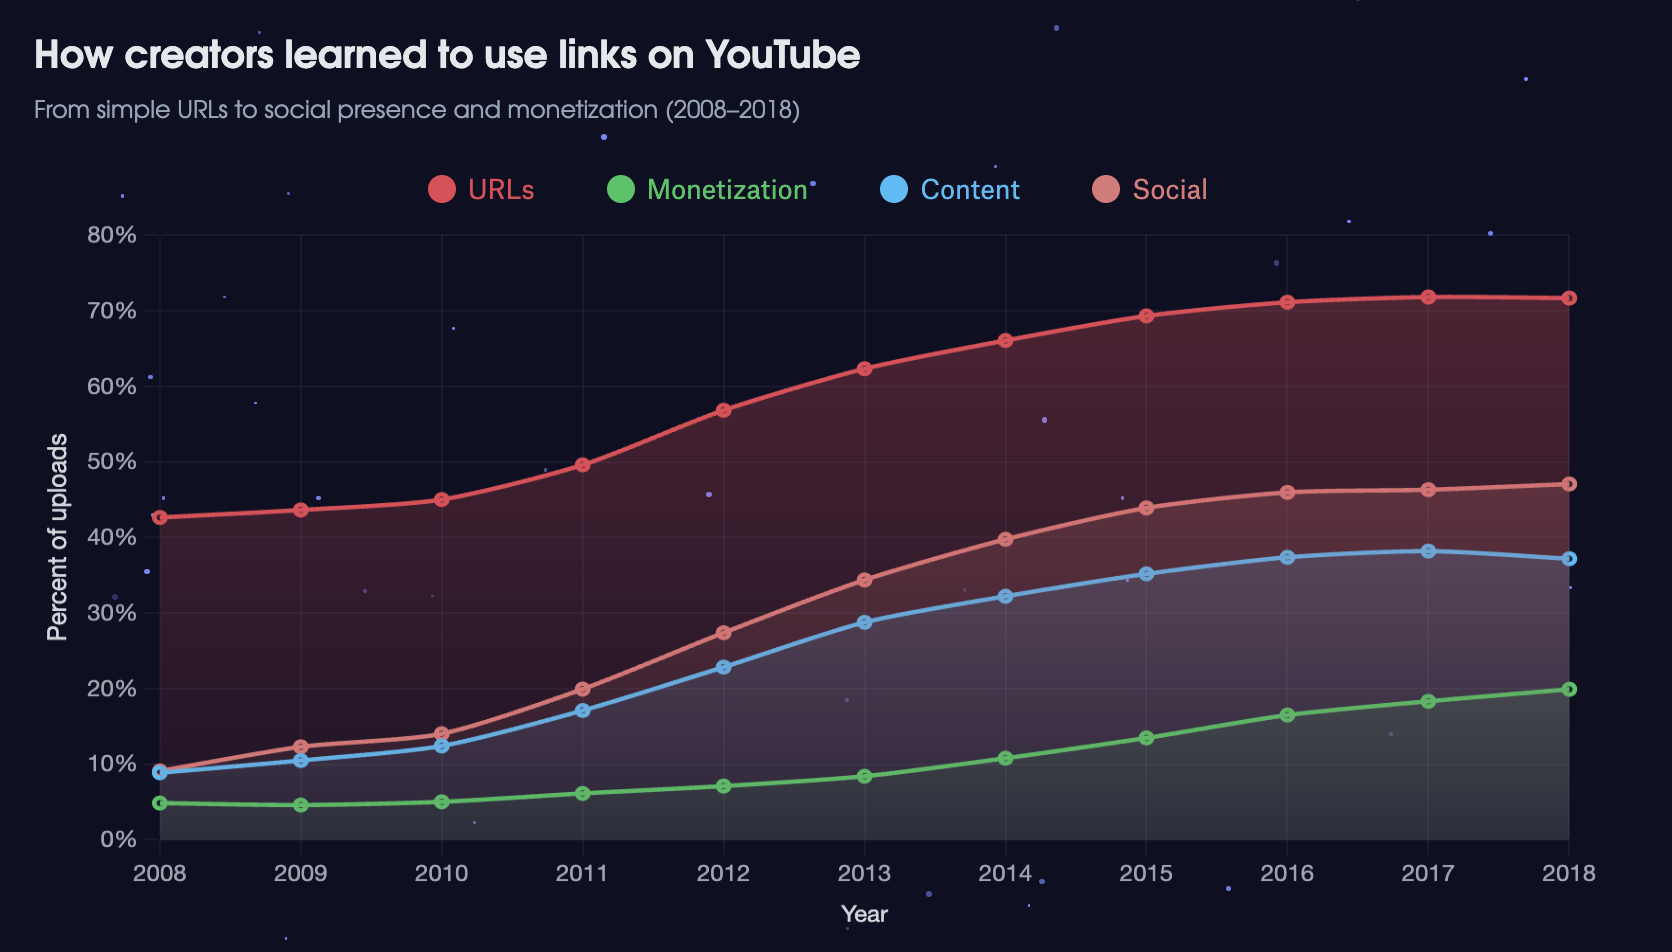

**Figure 2.** Share of videos containing at least one external link over time.

## 1.2 Normalizing Link Counts

The category-level results contain raw counts of videos with different link
types. To compare categories with different upload volumes, these counts are
converted into percentages relative to the total number of videos uploaded in
each year and category.

For each link type, the share is computed as:

$$
\text{percentage} = \frac{\text{videos with link type}}{\text{videos total}} \times 100
$$


### Reshaping to Long Format

After normalization, the dataset is reshaped from a wide format (one column per
link type) into a long format. In the long representation, each row corresponds
to a single `(year, yt_category, link_type)` observation, with `value_pct`
storing the percentage of videos containing that link type.

This format is used directly for plotting time trends and comparing link usage
across categories.


```metrics = [
    "videos_with_urls",
    "videos_with_monetization",
    "videos_with_content",
    "videos_with_social",
    "videos_with_entertainment",
    "videos_with_infrastructure",
    "videos_with_news",
]
for m in metrics:
    df_calculated[f"{m}_pct"] = (
        df_calculated[m] / df_calculated["videos_total"] * 100
    )

value_vars = [f"{m}_pct" for m in metrics]

df_long = df_calculated.melt(
    id_vars=["year", "yt_category"],
    value_vars=value_vars,
    var_name="metric",
    value_name="value_pct",
)

df_long["metric"] = (
    df_long["metric"]
        .str.replace("_pct", "", regex=False)
        .str.replace("videos_with_", "", regex=False)
)
```

```python
metrics = [
    "videos_with_urls",
    "videos_with_monetization",
    "videos_with_content",
    "videos_with_social"
]
for m in metrics:
    df_calculated[f"{m}_pct"] = (
        df_calculated[m] / df_calculated["videos_total"] * 100
    )

value_vars = [f"{m}_pct" for m in metrics]

df_long = df_calculated.melt(
    id_vars=["year", "yt_category"],
    value_vars=value_vars,
    var_name="metric",
    value_name="value_pct",
)

df_long["metric"] = (
    df_long["metric"]
        .str.replace("_pct", "", regex=False)
        .str.replace("videos_with_", "", regex=False)
)

df_calculated.head()

df_long.head()
```

## 1.3 Exploratory View of Link Usage Trends

Before preparing the final visualizations for the website, we created an
exploratory overview to inspect general link adoption trends across YouTube
categories.  This view shows small multiples of time series by category, with an
interactive selector to switch between different link types (e.g., monetization,
content, social).

The goal of this step is not presentation, but validation: to understand overall
patterns, relative timing, and category-level differences before designing more
focused visual narratives.


```python
df = df_calculated.copy()
cats = sorted(df["yt_category"].unique())
n_cats = len(cats)

cols = 4
rows = (n_cats + cols - 1) // cols

fig = make_subplots(
    rows=rows, cols=cols,
    shared_xaxes=True, shared_yaxes=True,
    subplot_titles=cats,
)

metric_names = ["urls", "monetization", "content", "social"]
metric_map = {m: "videos_with_" + m + "_pct" for m in metric_names}

traces = []
for i, cat in enumerate(cats):
    r = i // cols + 1
    c = i % cols + 1
    sub = df[df["yt_category"] == cat].sort_values("year")
    for m_name, col in metric_map.items():
        trace = go.Scatter(
            x=sub["year"],
            y=sub[col],
            mode="lines+markers",
            name=m_name,
            visible=(m_name == "monetization"),  # default
            showlegend=False,
        )
        fig.add_trace(trace, row=r, col=c)
        traces.append((cat, m_name))

buttons = []
for m_name in metric_names:
    visible = []
    for (_, trace_metric) in traces:
        visible.append(trace_metric == m_name)
    buttons.append(
        dict(
            label=m_name,
            method="update",
            args=[{"visible": visible},
                  {"title": f"% of videos with {m_name} links by category"}],
        )
    )

fig.update_layout(
    height=800,
    title="% of videos with monetization links by category",
    updatemenus=[dict(
        type="dropdown",
        x=0,
        y=1.15,
        showactive=True,
        buttons=buttons
    )],
    margin=dict(l=40, r=20, t=80, b=40),
)

fig.update_yaxes(title="% of videos")
fig.update_xaxes(title="year")

fig.show()

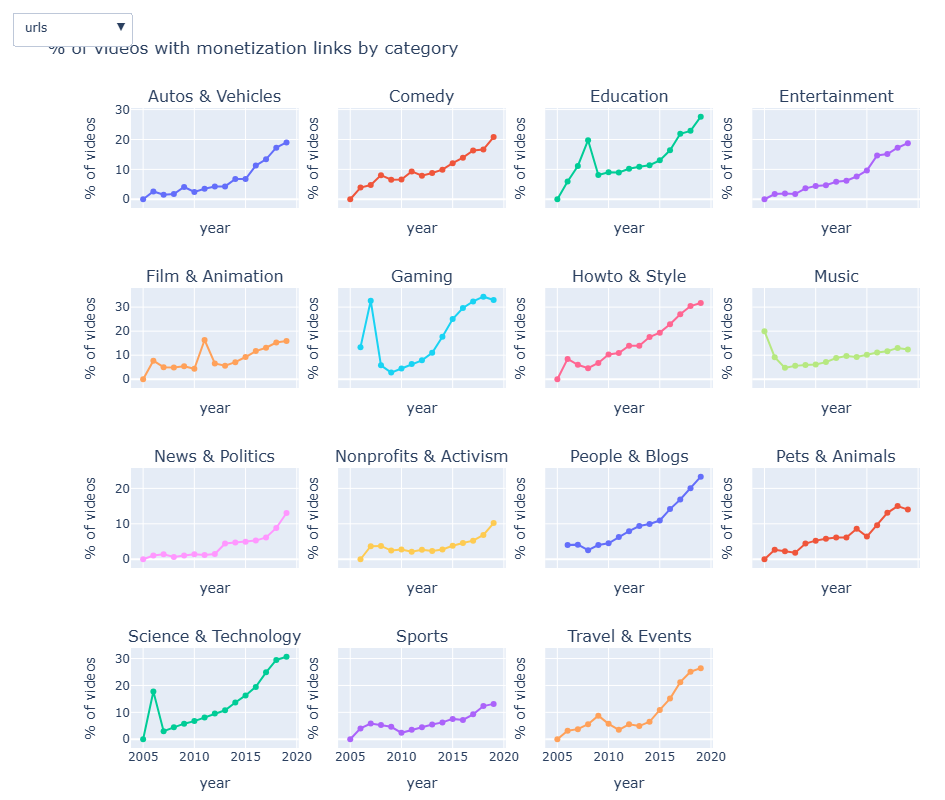

## 1.4 Exporting the Final Analysis Window (2008–2018) & Plots

The dataset is restricted to the 2008-2018 period to maintain consistency with the main analysis window and focus on YouTube's formative growth phase.

The filtered results are then exported as a record-oriented JSON file (`yt_stats_2008_2018.json`), where each entry corresponds to a single `(year, yt_category)` observation.  

```python 
df_0818 = df_calculated[
    (df_calculated["year"] >= 2008) &
    (df_calculated["year"] <= 2018)
].copy()

df_0818.to_json("data/yt_stats_2008_2018.json", orient="records")

print(json.dumps(df_0818.head(3).to_dict(orient="records"), indent=2))
```

### How Creators Learned to Use Links Across YouTube Categories

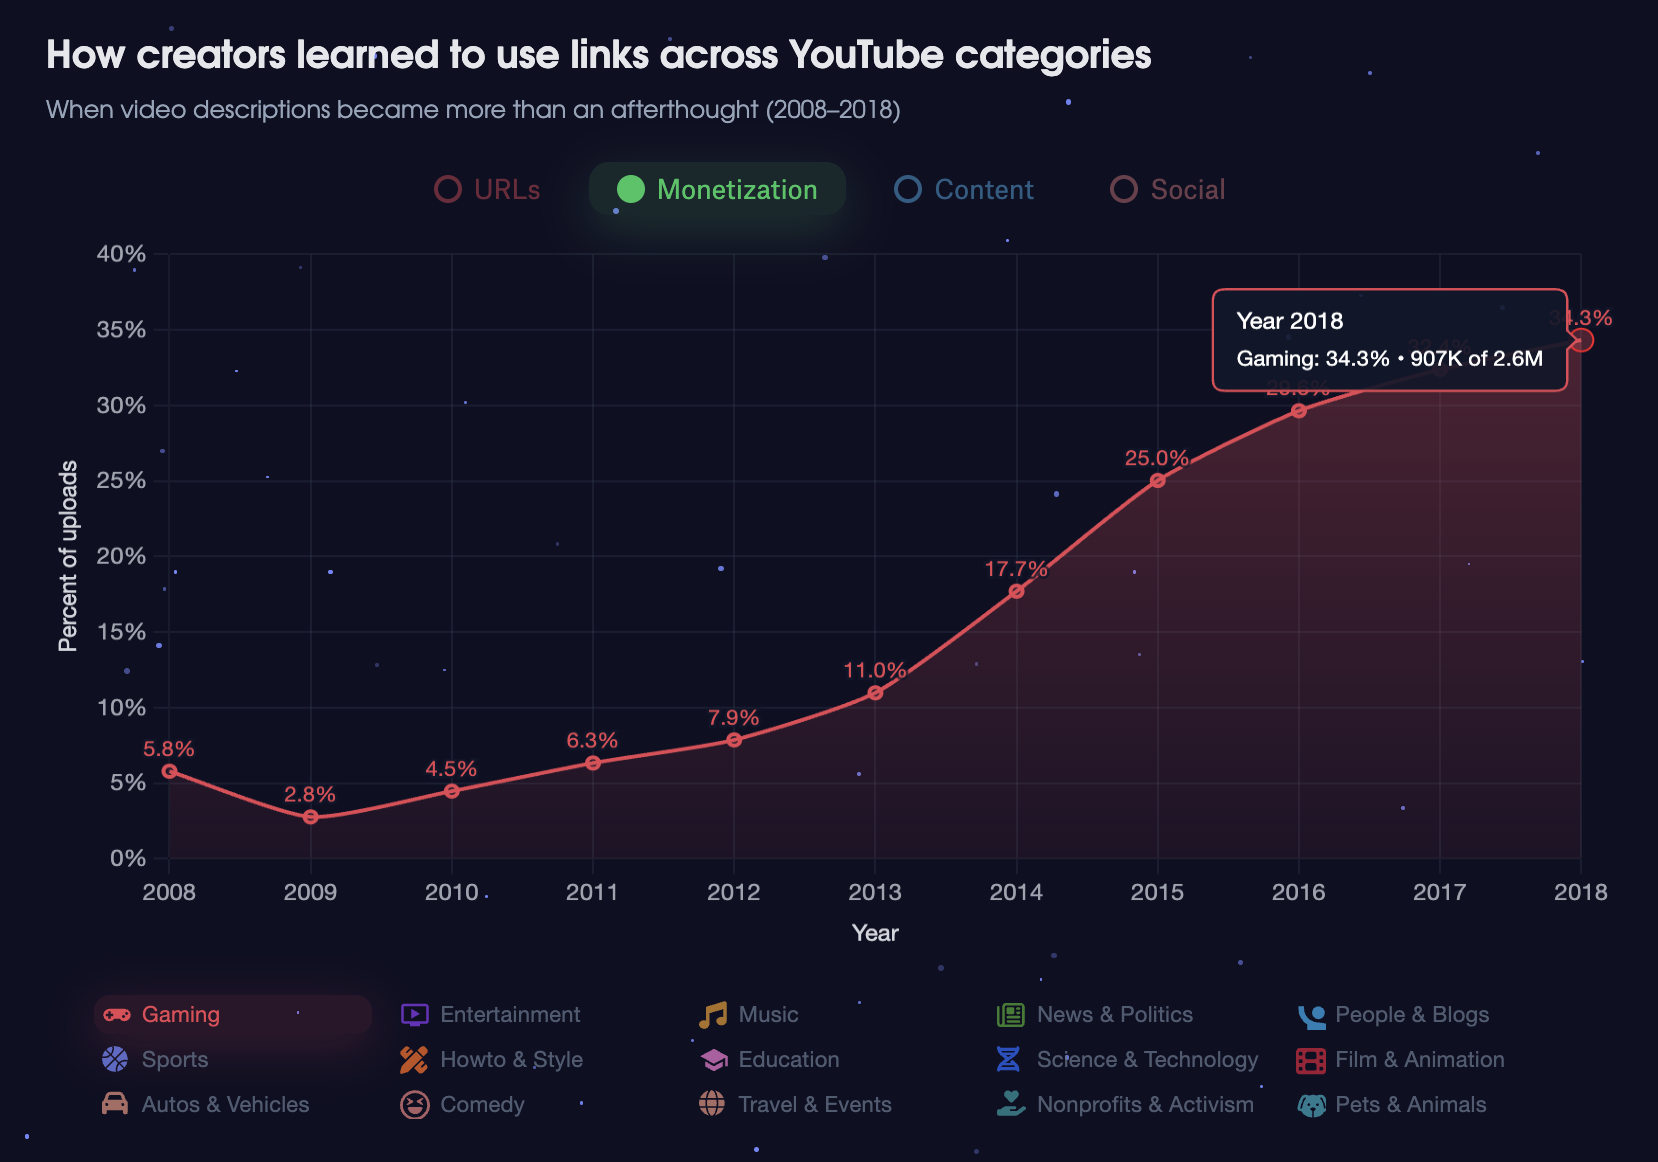

**Figure 3.** Evolution of link usage over time, shown separately for each YouTube category.


### Compare Link Usage Across Categories

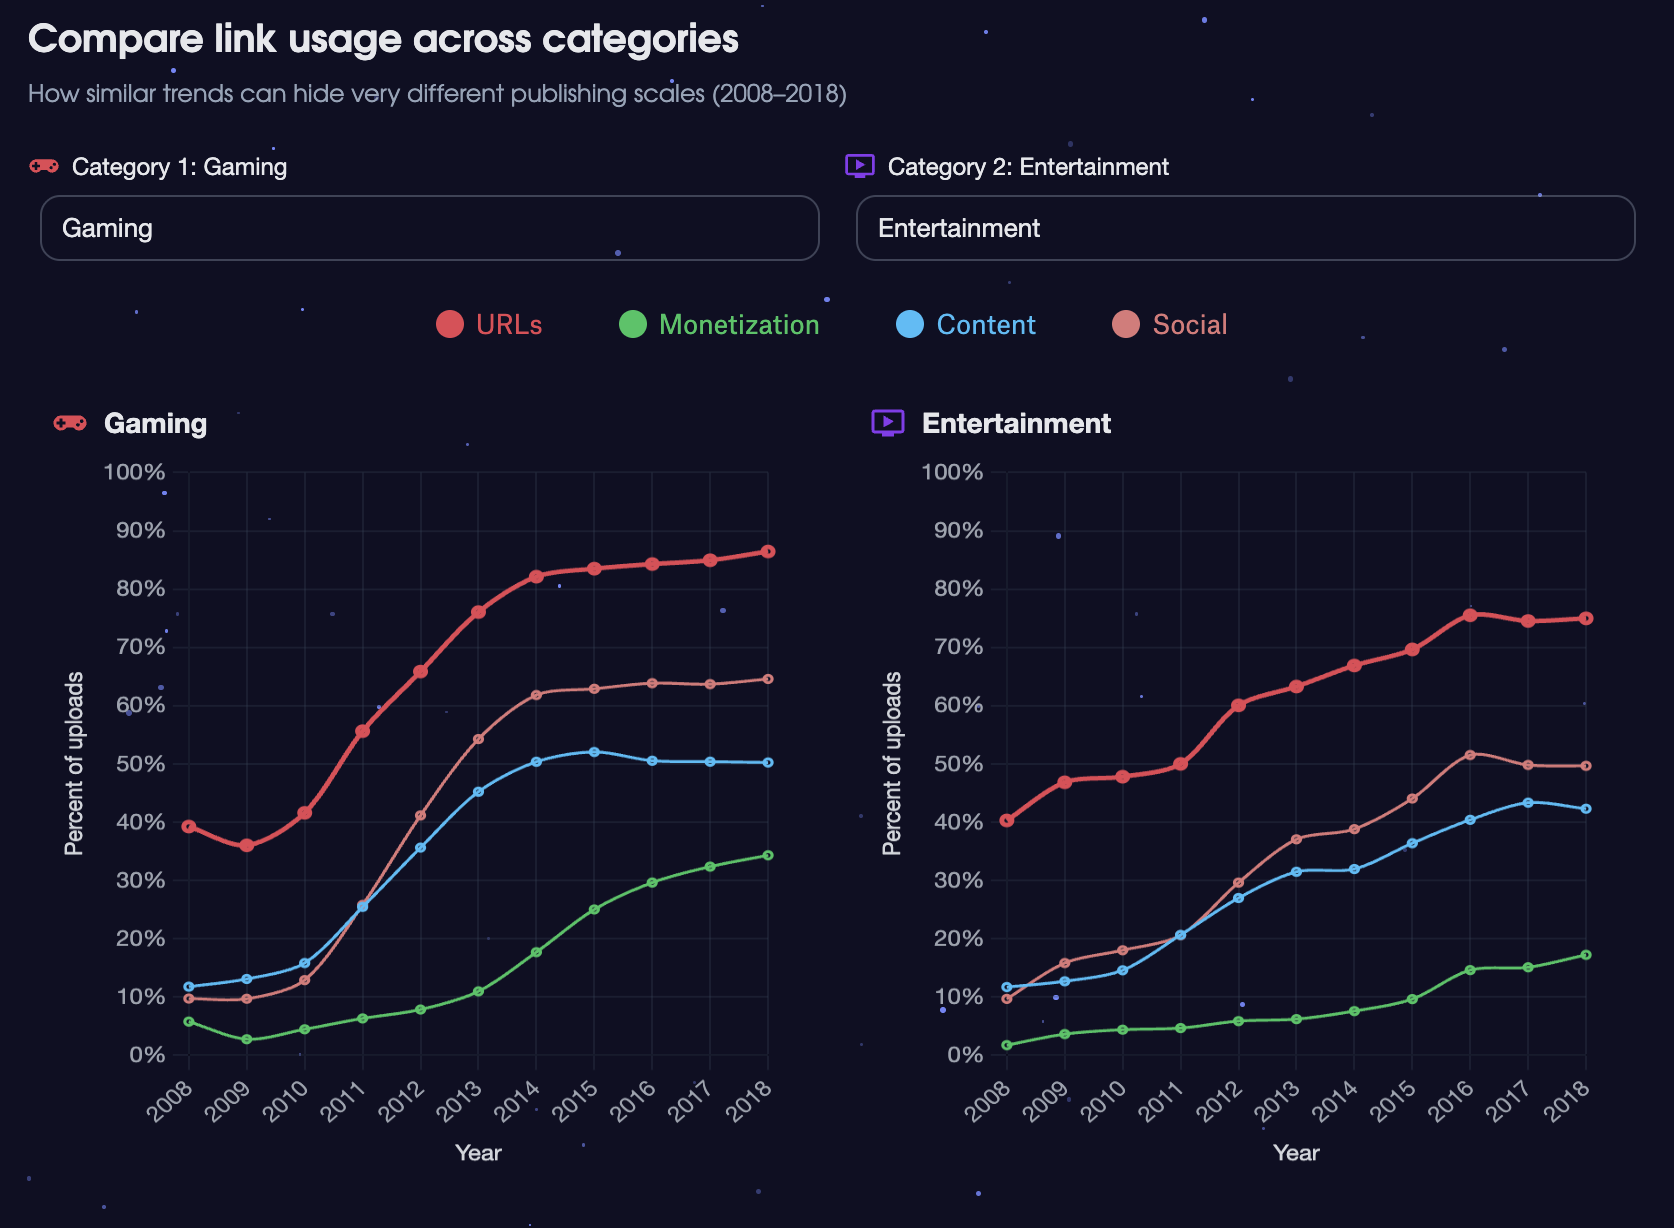 

**Figure 4.** Cross-category comparison of link usage rates in a given year.

# Channel Activity Status from YouTube API (2025)

## Introduction

We needed to find a way to get more up to date data, because our YouNiverse dataset only went up to 2019. We set up an enrichment pipeline. 

We start from channel data sourced from the YouNiverse dataset (df_channels_en.tsv.gz) and use the YouTube API (https://developers.google.com/youtube/v3).

We quickly hit our first roadblock: the API enforces a daily quota of 10k units per project. We initially added multiple API keys, which proved to be unsustainable, and was difficult to manage. So instead we redesigned the enrichment pipeline to work around this: a resumable, parquet based cache that stores partial enrichment results locally and reuses them across results. 





## API functions

We fetch channel metadata in batches.

```python
def fetch_channels_core(channel_ids: list[str], session: requests.Session) -> dict[str, dict]:
    out = {}
    ids = pd.Series(channel_ids).dropna().astype(str).unique().tolist()

    def to_int(x):
        try:
            return int(x)
        except Exception:
            return None

    for i in range(0, len(ids), 50):
        chunk = ids[i:i+50]
        data = yt_get(
            "channels",
            {"part": "snippet,statistics,contentDetails", "id": ",".join(chunk), "maxResults": 50},
            session=session,
        )
        items = {it["id"]: it for it in data.get("items", [])}

        for cid in chunk:
            it = items.get(cid)
            if not it:
                out[cid] = {"has_api": False}
                continue

            sn = it.get("snippet") or {}
            st = it.get("statistics") or {}
            cd = it.get("contentDetails") or {}
            uploads = ((cd.get("relatedPlaylists") or {}).get("uploads"))

            thumbs = sn.get("thumbnails") or {}
            avatar = (
                (thumbs.get("high") or {}).get("url")
                or (thumbs.get("medium") or {}).get("url")
                or (thumbs.get("default") or {}).get("url")
            )

            out[cid] = {
                "has_api": True,
                "channel_title_2025": sn.get("title"),
                "channel_avatar_url_2025": avatar,
                "subscriber_count_2025": to_int(st.get("subscriberCount")),
                "video_count_2025": to_int(st.get("videoCount")),
                "view_count_2025": to_int(st.get("viewCount")),
                "uploads_playlist_id": uploads,
            }

        time.sleep(0.02)

    return out
```

## APIs

We query each channel uploads playlist to get the most recent video id. Because this call is per channel, we run it concurrently.
```python
def _fetch_latest_video_id_one(uploads_pid: str, session: requests.Session) -> tuple[str | None, str | None]:
    data = yt_get(
        "playlistItems",
        {"part": "contentDetails,snippet", "playlistId": uploads_pid, "maxResults": 1},
        session=session,
    )
    items = data.get("items") or []
    if not items:
        return None, None
    it = items[0]
    cd = it.get("contentDetails") or {}
    sn = it.get("snippet") or {}
    return cd.get("videoId"), sn.get("title")

def fetch_latest_video_ids_concurrent(
    core_map: dict[str, dict],
    session: requests.Session,
    max_workers: int = 15
) -> dict[str, dict]:
    out = {cid: {"latest_video_id": None, "last_video_title_2025": None} for cid in core_map.keys()}

    tasks = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for cid, info in core_map.items():
            pid = info.get("uploads_playlist_id")
            if not info.get("has_api") or not pid:
                continue
            tasks.append((cid, ex.submit(_fetch_latest_video_id_one, pid, session)))

        for cid, fut in tasks:
            try:
                vid, title = fut.result()
                out[cid] = {"latest_video_id": vid, "last_video_title_2025": title}
            except Exception:
                out[cid] = {"latest_video_id": None, "last_video_title_2025": None}

    return out
```

## Parquet cache helpers

We store enrichment results in a local parquet cache keyed by `_channel_id_norm`. This allows us to resume the enrichment without repeating work.
```python

def _cache_path(cache_dir: str | Path) -> Path:
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir / "yt_enrichment_cache.parquet"

def load_cache_parquet(cache_dir: str | Path) -> pd.DataFrame:
    path = _cache_path(cache_dir)
    if not path.exists():
        return pd.DataFrame()
    return pd.read_parquet(path)

def upsert_cache_parquet(cache_dir: str | Path, new_rows: pd.DataFrame) -> None:
    path = _cache_path(cache_dir)
    if new_rows.empty:
        return

    if path.exists():
        old = pd.read_parquet(path)
        combined = pd.concat([old, new_rows], ignore_index=True)
        combined = combined.drop_duplicates(subset=["_channel_id_norm"], keep="last")
    else:
        combined = new_rows.drop_duplicates(subset=["_channel_id_norm"], keep="last")

    combined.to_parquet(path, index=False)
```

We also defined some function to orchestrate id normalization, cache reuse, chunked processing, API calls, activity classification, and the final merge back into the original dataframe.

We use the functions as follows: 

```python
df = df_channels.copy()

RUN_FULL_COMPUTATION = False  # set to True to recompute from the raw data

if RUN_FULL_COMPUTATION:
    df_extended = extend_df_with_youtube_fetch_resumable_parquet(
        df,
        channel_col="channel",
        year=2025,
        max_workers=15,
        cache_dir="cache/yt_parquet",
        resume=True,
        chunk_size_channels=8000,
    )
else:
    df_extended = pd.read_csv("cache/yt_parquet/df_extended.csv")
    df = df_extended.copy()
df_extended.head(3)


## Exploratory view of channel activity by category (pre-website)

Before exporting the final dataset for the website, we make some visualizations to look at how channel activity is distributed across content categories. 

Channels are grouped in two categories: active (uploaded at least once by November 2025) and not active. The goal of this is for a sanity check: we see the patterns and relative differences in activity, before we use the data for the website. This is not used on the main website and only serves as an intermediate task.


## Category activity aggregation data for the website visualization

We generate a compact JSON config for the visualizations for the website. Starting from the API-enriched dataframe, we compute the per-category counts of **active** and **not active** channels and sample representative channels based on subscriber size. One visual icon corresponds to approximately 200 channels. We normalize and validate the data, and categories are then sorted by total size. 

The final output is a lightweight JSON file with:
- **DATA**: category-level activity counts  
- **LINKS**: representative channels per category and activity band  
```python
OUT_JSON = "data/data_config_activity_v2_enriched_live.json"

df2 = normalize_activity_band(df_extended)
validate_activity_inputs(df2)

df2["subscribers_cc"] = pd.to_numeric(
    df2["subscribers_cc"], errors="coerce"
).fillna(0)

entries = []
for cat_label, df_cat in df2.groupby("category_cc", dropna=False):
    data_entry = make_category_counts(df_cat, cat_label, cat_label)
    links_entry = sample_representative_links(
        df_cat,
        unit=200,
        keep_fields=df2.columns.tolist(),
    )
    total = data_entry["active"] + data_entry["not_active"]
    entries.append((total, data_entry, links_entry))

entries.sort(key=lambda x: x[0], reverse=True)

DATA = [e[1] for e in entries]
LINKS = {e[1]["id"]: e[2] for e in entries}

config = {"DATA": DATA, "LINKS": LINKS}

with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print(f"wrote {OUT_JSON} | categories={len(DATA)}")

```

```json
{
  "DATA": [
    {
      "id": "Music",
      "label": "Music",
      "active": 14816,
      "not_active": 8077
    },
    {
      "id": "Entertainment",
      "label": "Entertainment",
      "active": 12950,
      "not_active": 7848
    },
      ...
  ]
}

{
  "LINKS": {
    "Music": {
      "active": [
        {
          "channel_title_2025": "T-Series",
          "subscriber_count_2025": 308000000,
          "latest_video_id": "OBLQTYgCaDo",
          "last_upload_utc_2025": "2025-12-15T11:28:12Z",
          "activity_band_2025": "active"
            ...
        },
        {
          "channel_title_2025": "Zee Music Company",
          "subscriber_count_2025": 121000000,
          "latest_video_id": "_Ba8ZuEgXRM",
          "last_upload_utc_2025": "2025-12-15T09:01:01Z",
          "activity_band_2025": "active"
            ...
        }
      ]
    }
  }
}

```

After, we save the enriched dataframe for downstream analysis and visualization.


## Our website
### https://ri-ru.github.io/ADA-website/

In the following, we look at our design process for the website, and focus on some key moments that shaped our journey :-)


# Chapter 1: Inspiration for our design

### Initial inspiration and sketches 

The first part of the job was very important, as it would set the tone for the rest of our datastory. As a large team effort, we discussed a great deal about what datastory we wanted. We looked at some examples together to reference our website design and flow, we created sketches, drew inspiration from others, and made mockups. It did not look good at first, and it was hard to communicate what the website should become.But, we did have a general idea of the structure.

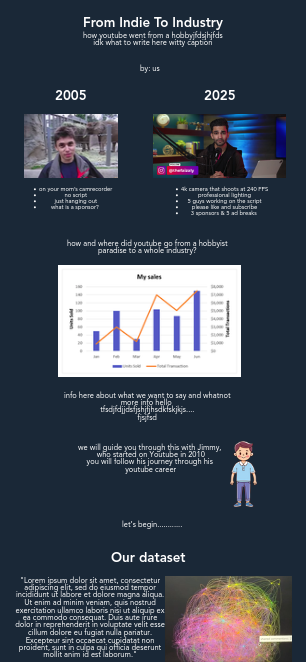

Here's some beautiful datastories and graphics we used as inspiration:


https://pudding.cool/2021/04/music-bubble/    |  [www.denizcemonduygu.com/](https://www.denizcemonduygu.com/) | https://www.karim.news/
:-------------------------:|:-------------------------:|:-------------------------:
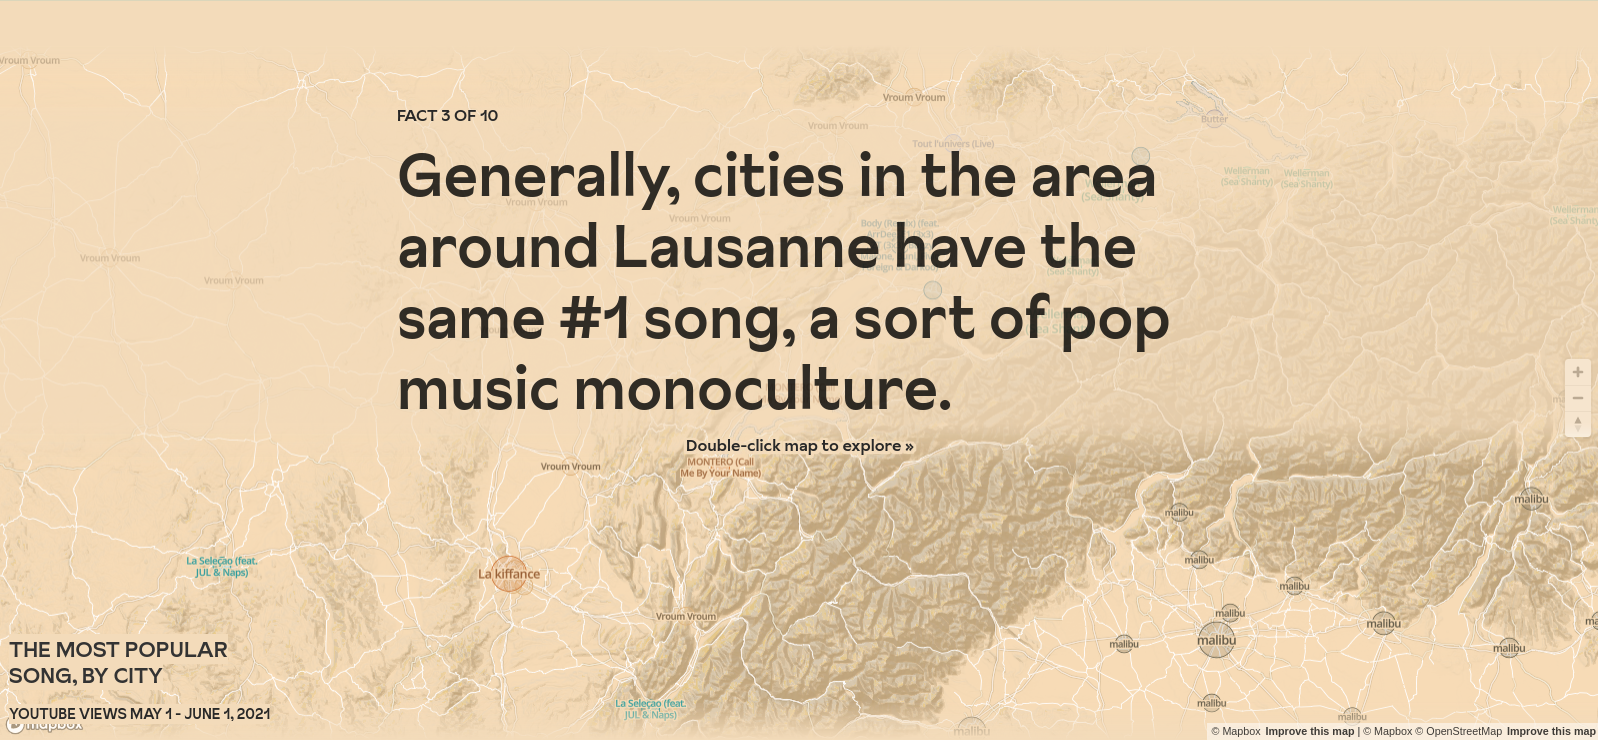 |  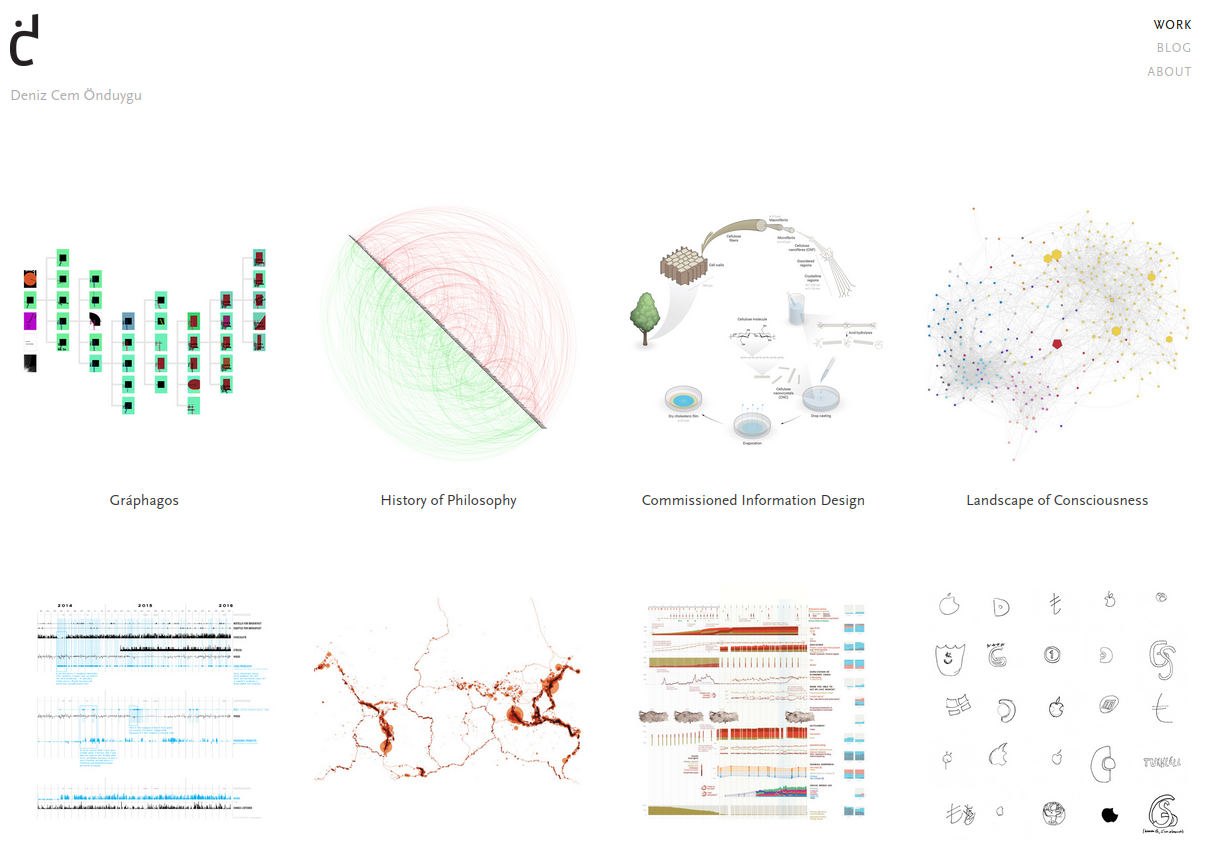 | 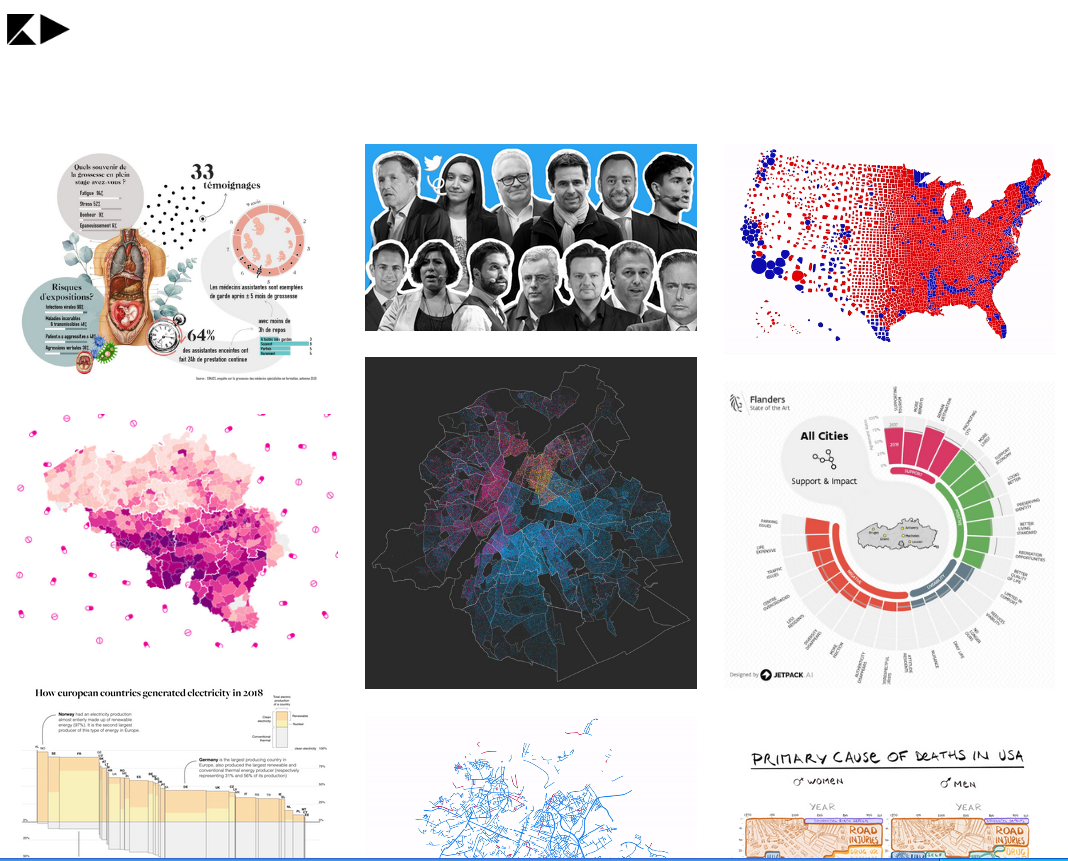




We also defined some function to orchestrate id normalization, cache reuse, chunked processing, API calls, activity classification, and the final merge back into the original dataframe.

We use the functions as follows: 

```df = df_channels.copy()

RUN_FULL_COMPUTATION = False  # set to True to recompute from the raw data

if RUN_FULL_COMPUTATION:
    df_extended = extend_df_with_youtube_fetch_resumable_parquet(
        df,
        channel_col="channel",
        year=2025,
        max_workers=15,
        cache_dir="cache/yt_parquet",
        resume=True,
        chunk_size_channels=8000,
    )
else:
    df_extended = pd.read_csv("cache/yt_parquet/df_extended.csv")
    df = df_extended.copy()
df_extended.head(3)```


# Chapter 2: The nitty-gritty of the website - hosting

<!-- 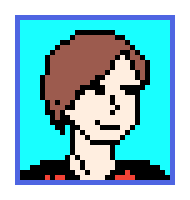 -->
         
**Question: how to create and host a website if you have never done it before?**

We initially explored Jekyll for hosting, but it wasn't ideal for our continuous narrative flow—it's better suited for blog-style posts. We wanted something more dynamic and interactive to tell our story.

Eventually, building on a template used by our inspirations, we settled on SvelteKit (Svelte 5). Despite the initial learning curve, it seems like certainly the right decision now! Without boring you with how Svelte is better than other frameworks (hint: it is)... Unlike frameworks like React that ship their runtime to the browser, Svelte compiles components to optimized vanilla JavaScript at build time. So, smaller bundles and faster load times, all with incredible flexibility and reactivity! 

For hosting, we use GitHub Pages, so we don't need to host our own server nor have any database. The build process outputs pure HTML/CSS/JS files to the build directory, which GitHub serves directly. Very convenient!

Below is our SvelteKit config for GitHub Pages hosting.

```js
const config = {
    compilerOptions: {
        runes: true
    },
    preprocess,
    kit: {
        adapter: adapterStatic({
            pages: 'build',
            assets: 'build',
            fallback: 'index.html',
            precompress: false,
            strict: false
        }),
        paths: {
            base: dev ? '' : '/ADA-website'
        }
    }
};

export default config;
```

# Chapter 3: Snippets of Implementations

###  Our narrative - the explanation 

Our datastory narrative is about a Youtuber named Jimmy, who recently started his channel and wants to get paid for it. He finds a "get rich quick scheme" course online, that looks quite suspicious, but he borrows his mom's credit card anyway and buys the course. Instead, surprise: This course is actually a collection of skilled analysts, and provide high quality data analysis to help Jimmy understand what kind of Youtuber he needs to become to also make money from his channel! 

To tell this story and allow the reader to get lost in the narrative (hopefully ;)), we personify Jimmy through a low quality video, and through a serious of texting messages between him and the analysts. The story is meant to be light and easy to read, with stretches of analyses followed by some silly jokes. We show that there is real interaction between the analysts and Jimmy as they show and describe plots to which Jimmy asks questions if he's curious. 

Jimmy's video: 

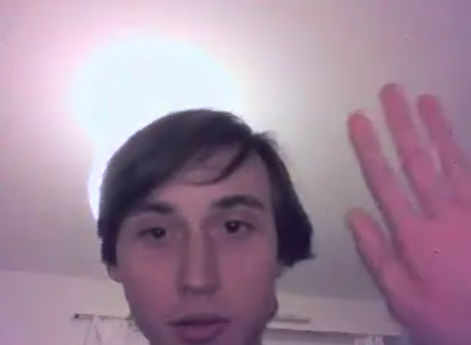

### Data Storage

To make every member's analysis addition easier, we used ArchieML with Google Docs. This way, any member could add their own text messages without needing to touch the code, no pushing tiny changes, all was synced at once.

How it works:
- Content lives in Google Docs to be added/edited
- Synced to JSON & CSV
- Parsed into chat bubbles with corresponding avatars

Team members write dialogue like this:

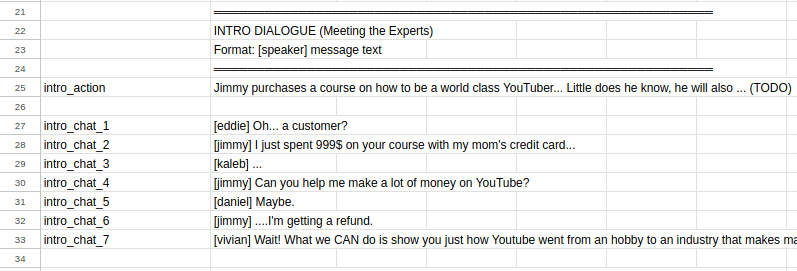

Our generated json is like so:
   ```json
   {
     "intro_chat_1": "[eddie] Oh... a customer?",
     "intro_chat_2": "[jimmy] I just spent 999$ on my mom's credit card...",
     "intro_chat_7": "[vivian] Wait! What we CAN do is show you..."
   }
   ```




### The Dialogue System

In our main file Index.svelte, the  `parseChatMessage()` function uses regex to extract the speakers name from the Json above#, the message and the placement on which side to put the speaker (Jimmy on the right)


   ```javascript
   function parseChatMessage(str) {
     const match = str.match(/^\[(\w+)\]\s*(.*)$/);
     if (match) {
       const speakerKey = match[1].toLowerCase();
       const text = match[2];
       const side = speakerKey === 'jimmy' ? 'right' : 'left';
       return { speaker: match[1], text, side };
     }
     return { speaker: "Unknown", text: str, side: "left" };
   }
   ```


We then have to display the pixel art, support the HTML formatting, and making cute speech bubbles. 

To configure the speakers, we define each team member with the correspoinding pixel avatar: 

```javascript
const speakers = {
    jimmy: { avatar: "assets/pixel_art/jan.gif", name: "Jimmy" },
    eddie: { avatar: "assets/pixel_art/ender.gif", name: "Eddie" },
    kaleb: { avatar: "assets/pixel_art/kalan.gif", name: "Kaleb" },
    daniel: { avatar: "assets/pixel_art/danael.gif", name: "Daniel" },
    vivian: { avatar: "assets/pixel_art/veronika.gif", name: "Vivian" },
    siba: { avatar: "assets/pixel_art/siba.gif", name: "Siba" }
};

function getSpeaker(id) {
    return speakers[id.toLowerCase()] || 
           { avatar: "assets/pixel_art/default.gif", name: id };
}
```

Using Svelte 5's `{#snippet}` syntax, we created a reusable dialogue component that handles message rendering:


```js
{#snippet dialogue(messages)}
    <div class="dialogue">
        {#each messages as msg, i}
            <div class="msg {msg.side}" style="--delay: {i * 0.1}s">
                {#if msg.side === "left"}
                    <!-- Experts on LEFT -->
                    <div class="avatar-col">
                        <img class="avatar-img" 
                             src={getSpeaker(msg.speaker).avatar} 
                             alt={msg.speaker} />
                        <span class="speaker-name">
                            {getSpeaker(msg.speaker).name}
                        </span>
                    </div>
                    <div class="bubble bubble-left">
                        <p>{@html msg.text}</p>
                    </div>
                {:else}
                    <!-- Jimmy on RIGHT -->
                    <div class="bubble bubble-right">
                        <p>{@html msg.text}</p>
                    </div>
                    <div class="avatar-col">
                        <img class="avatar-img" 
                             src={getSpeaker(msg.speaker).avatar} 
                             alt={msg.speaker} />
                        <span class="speaker-name">
                            {getSpeaker(msg.speaker).name}
                        </span>
                    </div>
                {/if}
            </div>
        {/each}
    </div>
{/snippet}
```

With these tools, we can render all sorts of dialogues and texts! 

### The design & pixel art 

To draw the avatars, we used this website: https://www.pixilart.com/draw to draw them by hand.

To prevent the pixel art from being blurry, we used some css features: 


```css
.avatar-img {
    image-rendering: pixelated;
    image-rendering: crisp-edges;
    -webkit-image-rendering: pixelated;
    transform: translateZ(0);
}
```

The `image-rendering: pixelated` prevents the browser from smoothing our pixel art, and Jimmy's avatar gets `transform: scaleX(-1)` to mirror it for chat-like view.



### Overall design

A big problem we had, with so many team members working on the same data story, is how to make the website look good and consistently use the same styles. 

We established a unified color system that was necessary as each plot differs, using a Style Dictionary to maintain color consistency across CSS and JavaScript. We define design tokens once, and then generate them for both environments.

Source of design truth: design-system.css




### How charts are rendered 

We render charts by directly importing Svelte components. We have two charties libraries in use: Echarts and Chart.js. Each of them is converted to a reusable Svelte component, which makes it very easy to use inside the main page and makes updating it very modular. 

```js
import KalanChart0 from "./KalanChart0.svelte"
import KalanChart1 from "./KalanChart1.svelte"
import Compare_1 from "./Compare_1.svelte"
import VisualizationFocus from "./VisualizationFocus.svelte"
// etc.

<KalanChart0/>
<Compare_1 />
<VisualizationDumbbell />

# Channel Activity Status from YouTube API (2025)

## Introduction

We needed to find a way to get more up to date data, because our YouNiverse dataset only went up to 2019. We set up an enrichment pipeline. 

We start from channel data sourced from the YouNiverse dataset (df_channels_en.tsv.gz) and use the YouTube API (https://developers.google.com/youtube/v3).

We quickly hit our first roadblock: the API enforces a daily quota of 10k units per project. We initially added multiple API keys, which proved to be unsustainable, and was difficult to manage. So instead we redesigned the enrichment pipeline to work around this: a resumable, parquet based cache that stores partial enrichment results locally and reuses them across results. 





## API functions

We fetch channel metadata in batches.

```python
def fetch_channels_core(channel_ids: list[str], session: requests.Session) -> dict[str, dict]:
    out = {}
    ids = pd.Series(channel_ids).dropna().astype(str).unique().tolist()

    def to_int(x):
        try:
            return int(x)
        except Exception:
            return None

    for i in range(0, len(ids), 50):
        chunk = ids[i:i+50]
        data = yt_get(
            "channels",
            {"part": "snippet,statistics,contentDetails", "id": ",".join(chunk), "maxResults": 50},
            session=session,
        )
        items = {it["id"]: it for it in data.get("items", [])}

        for cid in chunk:
            it = items.get(cid)
            if not it:
                out[cid] = {"has_api": False}
                continue

            sn = it.get("snippet") or {}
            st = it.get("statistics") or {}
            cd = it.get("contentDetails") or {}
            uploads = ((cd.get("relatedPlaylists") or {}).get("uploads"))

            thumbs = sn.get("thumbnails") or {}
            avatar = (
                (thumbs.get("high") or {}).get("url")
                or (thumbs.get("medium") or {}).get("url")
                or (thumbs.get("default") or {}).get("url")
            )

            out[cid] = {
                "has_api": True,
                "channel_title_2025": sn.get("title"),
                "channel_avatar_url_2025": avatar,
                "subscriber_count_2025": to_int(st.get("subscriberCount")),
                "video_count_2025": to_int(st.get("videoCount")),
                "view_count_2025": to_int(st.get("viewCount")),
                "uploads_playlist_id": uploads,
            }

        time.sleep(0.02)

    return out
```

We query each channel uploads playlist to get the most recent video id. Because this call is per channel, we run it concurrently.
```python
def _fetch_latest_video_id_one(uploads_pid: str, session: requests.Session) -> tuple[str | None, str | None]:
    data = yt_get(
        "playlistItems",
        {"part": "contentDetails,snippet", "playlistId": uploads_pid, "maxResults": 1},
        session=session,
    )
    items = data.get("items") or []
    if not items:
        return None, None
    it = items[0]
    cd = it.get("contentDetails") or {}
    sn = it.get("snippet") or {}
    return cd.get("videoId"), sn.get("title")

def fetch_latest_video_ids_concurrent(
    core_map: dict[str, dict],
    session: requests.Session,
    max_workers: int = 15
) -> dict[str, dict]:
    out = {cid: {"latest_video_id": None, "last_video_title_2025": None} for cid in core_map.keys()}

    tasks = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for cid, info in core_map.items():
            pid = info.get("uploads_playlist_id")
            if not info.get("has_api") or not pid:
                continue
            tasks.append((cid, ex.submit(_fetch_latest_video_id_one, pid, session)))

        for cid, fut in tasks:
            try:
                vid, title = fut.result()
                out[cid] = {"latest_video_id": vid, "last_video_title_2025": title}
            except Exception:
                out[cid] = {"latest_video_id": None, "last_video_title_2025": None}

    return out
```


## Parquet cache helpers

We store enrichment results in a local parquet cache keyed by `_channel_id_norm`. This allows us to resume the enrichment without repeating work.
```python

def _cache_path(cache_dir: str | Path) -> Path:
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir / "yt_enrichment_cache.parquet"

def load_cache_parquet(cache_dir: str | Path) -> pd.DataFrame:
    path = _cache_path(cache_dir)
    if not path.exists():
        return pd.DataFrame()
    return pd.read_parquet(path)

def upsert_cache_parquet(cache_dir: str | Path, new_rows: pd.DataFrame) -> None:
    path = _cache_path(cache_dir)
    if new_rows.empty:
        return

    if path.exists():
        old = pd.read_parquet(path)
        combined = pd.concat([old, new_rows], ignore_index=True)
        combined = combined.drop_duplicates(subset=["_channel_id_norm"], keep="last")
    else:
        combined = new_rows.drop_duplicates(subset=["_channel_id_norm"], keep="last")

    combined.to_parquet(path, index=False)
```

We also defined some function to orchestrate id normalization, cache reuse, chunked processing, API calls, activity classification, and the final merge back into the original dataframe.

We use the functions as follows: 

```python
df = df_channels.copy()

RUN_FULL_COMPUTATION = False  # set to True to recompute from the raw data

if RUN_FULL_COMPUTATION:
    df_extended = extend_df_with_youtube_fetch_resumable_parquet(
        df,
        channel_col="channel",
        year=2025,
        max_workers=15,
        cache_dir="cache/yt_parquet",
        resume=True,
        chunk_size_channels=8000,
    )
else:
    df_extended = pd.read_csv("cache/yt_parquet/df_extended.csv")
    df = df_extended.copy()
df_extended.head(3)


## Exploratory view of channel activity by category (pre-website)

Before exporting the final dataset for the website, we make some visualizations to look at how channel activity is distributed across content categories. 

Channels are grouped in two categories: active (uploaded at least once by November 2025) and not active. The goal of this is for a sanity check: we see the patterns and relative differences in activity, before we use the data for the website. This is not used on the main website and only serves as an intermediate task.

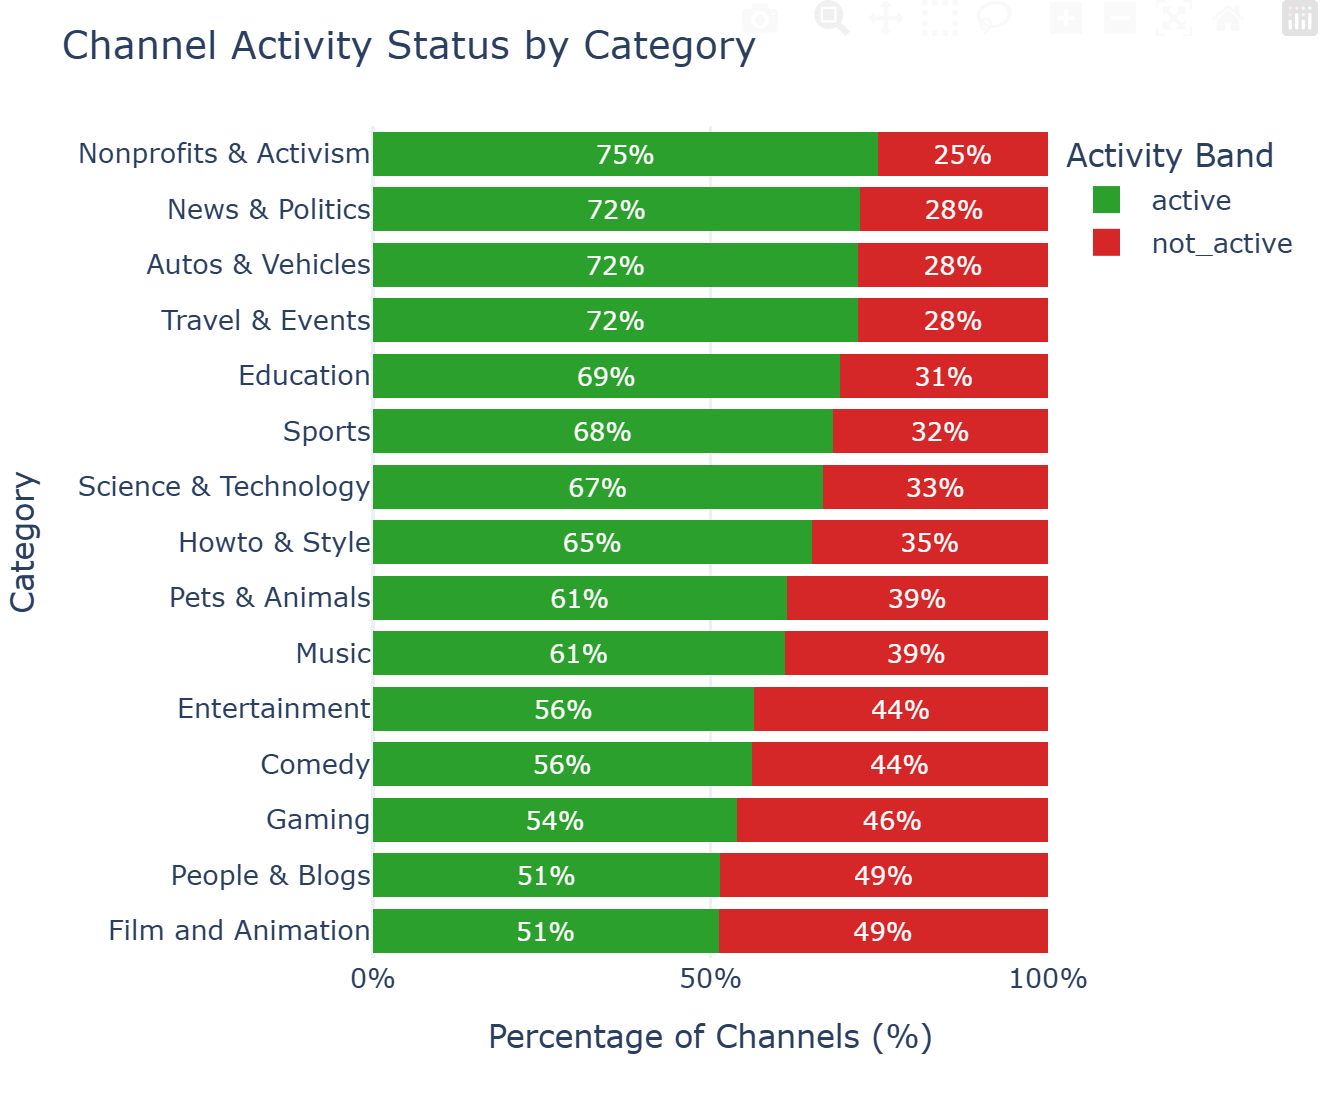


## Category activity aggregation data for the website visualization

We generate a compact JSON config for the visualizations for the website. Starting from the API-enriched dataframe, we compute the per-category counts of **active** and **not active** channels and sample representative channels based on subscriber size. One visual icon corresponds to approximately 200 channels. We normalize and validate the data, and categories are then sorted by total size. 

The final output is a lightweight JSON file with:
- **DATA**: category-level activity counts  
- **LINKS**: representative channels per category and activity band  
```python
OUT_JSON = "data/data_config_activity_v2_enriched_live.json"

df2 = normalize_activity_band(df_extended)
validate_activity_inputs(df2)

df2["subscribers_cc"] = pd.to_numeric(
    df2["subscribers_cc"], errors="coerce"
).fillna(0)

entries = []
for cat_label, df_cat in df2.groupby("category_cc", dropna=False):
    data_entry = make_category_counts(df_cat, cat_label, cat_label)
    links_entry = sample_representative_links(
        df_cat,
        unit=200,
        keep_fields=df2.columns.tolist(),
    )
    total = data_entry["active"] + data_entry["not_active"]
    entries.append((total, data_entry, links_entry))

entries.sort(key=lambda x: x[0], reverse=True)

DATA = [e[1] for e in entries]
LINKS = {e[1]["id"]: e[2] for e in entries}

config = {"DATA": DATA, "LINKS": LINKS}

with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print(f"wrote {OUT_JSON} | categories={len(DATA)}")

```

```json
{
  "DATA": [
    {
      "id": "Music",
      "label": "Music",
      "active": 14816,
      "not_active": 8077
    },
    {
      "id": "Entertainment",
      "label": "Entertainment",
      "active": 12950,
      "not_active": 7848
    },
      ...
  ]
}

{
  "LINKS": {
    "Music": {
      "active": [
        {
          "channel_title_2025": "T-Series",
          "subscriber_count_2025": 308000000,
          "latest_video_id": "OBLQTYgCaDo",
          "last_upload_utc_2025": "2025-12-15T11:28:12Z",
          "activity_band_2025": "active"
            ...
        },
        {
          "channel_title_2025": "Zee Music Company",
          "subscriber_count_2025": 121000000,
          "latest_video_id": "_Ba8ZuEgXRM",
          "last_upload_utc_2025": "2025-12-15T09:01:01Z",
          "activity_band_2025": "active"
            ...
        }
      ]
    }
  }
}

```